Código creado por el Dr. Erick Correa Padilla

FES Zaragoza UNAM.


Este código está para ayudarte a predecir propiedades de nuevas sustancias, úsalo con cuidado.




Créditos a:
Cristopher Verde

# ANTECEDENTES
Instala las versiones más recientes de numpy y pandas.

In [1]:
import sys
import numpy as np

print("Python:", sys.version)
print("NumPy:", np.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3


In [2]:
import scipy
import sklearn

print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

print("NUMPY + SCIPY + SKLEARN OK")

SciPy: 1.16.3
Scikit-learn: 1.6.1
NUMPY + SCIPY + SKLEARN OK


In [3]:
try:
    import umap
    print("UMAP:", umap.__version__)
    print("UMAP OK")
except Exception as e:
    print("ERROR UMAP:")
    print(type(e).__name__, e)

UMAP: 0.5.12
UMAP OK


# IMPORTAR LIBRERIAS



Bibliotecas a utilizar

- rdkit: Para manipulación de estructuras moleculares, cálculos de descriptores básicos

- mordred: Para descriptores moleculares

- molplotly: Para visualización de moléculas en gráficos interactivos

In [4]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      ! pip install numpy --upgrade # Ensure numpy is updated to a compatible version
      ! pip install rdkit
      pbar.update(30)
      ! pip install mordredcommunity
      pbar.update(60)
      ! pip install molplotly
      !pip install umap-learn
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [5]:
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      import numpy as np
      import pandas as pd
      import seaborn as sns
      from mordred import Calculator, descriptors
      from dash import Dash, dcc, html, Input, Output
      #from tqdm.auto import tqdm, trange
      from matplotlib import pyplot as plt
      import molplotly
      import plotly.graph_objects as go
      import plotly.express as px
      pbar.update(50)
      from rdkit.Chem import AllChem
      from rdkit import Chem
      from rdkit.Chem import Descriptors
      from rdkit.ML.Descriptors import MoleculeDescriptors
      from rdkit.ML.Cluster import Butina
      from rdkit import DataStructs
      from rdkit.Chem import PandasTools
      #import umap
      pbar.update(80)
      import sklearn
      from sklearn.svm import SVR, OneClassSVM
      from sklearn.pipeline import Pipeline
      from sklearn.decomposition import PCA
      from sklearn.ensemble import RandomForestRegressor
      from sklearn.model_selection import KFold, StratifiedShuffleSplit
      from sklearn.preprocessing import StandardScaler
      from sklearn.feature_selection import SelectFromModel, VarianceThreshold
      from sklearn.impute import SimpleImputer
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [6]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel, VarianceThreshold

## Auxiliares

Se definen clases y funciones auxiliares que nos van a servir más adelante.

In [7]:
# función de Culsterificación
def TaylorButina_Cluster(fpts, distThresh = 0.61):
    # Genera la matriz de distancia
    dist_matrix = []
    nfpts = len(fpts)
    for i in tqdm.notebook.tqdm(range(1,nfpts)):
        # generate Tanimoto similary
        Tanimoto_coefficients = DataStructs.BulkTanimotoSimilarity(fpts[i],fpts[:i])
        dist_matrix.extend([1 - j for j in Tanimoto_coefficients])
    #Cluster the Tanimoto Scores using Butina:
    clusters = Butina.ClusterData(dist_matrix, nfpts, distThresh, isDistData=True)
    cluster_id_list = [0] * nfpts
    for idx,cluster in enumerate(clusters,1):
        for member in cluster:
            cluster_id_list[member] = idx
    return cluster_id_list

In [8]:
# función que regresa el puntaje de validación (Score)
def Score_cv(model, x, y, metrics="r2"):
    res = sklearn.model_selection.cross_validate(pipeline,
                                                 x_train, y,
                                                 scoring=metrics,
                                                 cv=CV_SPLITTER, n_jobs=-1)
    if isinstance(metrics, str):
        return np.mean(res["test_score"])
    return {metric: np.mean(res[f"test_{metric}"]) for metric in metrics}

In [9]:
# Regresa un dataframe con datos generales de un entrenamiento completo
# metric: la metrica a usar para evaluar
def validate_summary(metric):
    scorer = sklearn.metrics.get_scorer(metric)
    df = pd.DataFrame(index=[metric], data={
        "train": scorer(pipeline, x_train, y_train),
        "cv": Score_cv(pipeline, x_train, y_train, metrics=metric),
        "test": scorer(pipeline, x_test, y_test),
    })
    return df

In [10]:
# clase que nos dice si hay elementos afuera del dominio de aplicación usando el método de leverage
class LeverageMethod(sklearn.base.BaseEstimator):
    def fit(self, x, y=None):
        self.normal_mat = np.linalg.inv(x.T @ x)
        self.n_samples = x.shape[0]
        self.n_features = x.shape[1]
        return self

    def decision_function(self, x):
        leverages = np.diagonal(x @ self.normal_mat @ x.T)
        leverages = leverages - self.threshold_
        # leverages = self.threshold_ - leverages
        return leverages

    def predict(self, x):
        leverages = self.decision_function(x)
        preds = np.where(leverages < 0, -1, 1)
        return preds

    @property
    def threshold_(self):
        return 3*self.n_features/self.n_samples

In [11]:
# función que regresa el nombre de un stimador de sklearn
# model: el modelo a extraer el nombre
# returns: el nombre del modelo
def mname(model):
    return model.__class__.__name__

In [12]:
# Función que nos dice si hay elementos afuera del dominio de aplicación usando el método de leverage con las residuales estandarizadas
# nos devueleve el valor de H en un dataframe llamado df
def standardize_residuals(model):
    transformer = pipeline[:-1]
    estimator = pipeline[-1]
    df = pd.DataFrame(columns=["Score", "Standardized_Residual", "fraction"])

    splits = [(x_train, y_train, "train"), (x_test, y_test, "test")]
    for (x, y, fraction) in splits:
        z = transformer.transform(x)
        Score = model.decision_function(z)
        res = estimator.predict(z) - y
        # Standardize residuals
        standardized_res = (res - np.mean(res)) / np.std(res)
        df_ = pd.DataFrame({"Score": Score, "Standardized_Residual": standardized_res,
                            "fraction": fraction})
        df = pd.concat([df, df_])
    return df

In [13]:
# Guarda como nuevo dataframe la tabla de valores experimentales, calculados y la fracción a la que pertenecen
def validate_true_vs_pred():
    df = pd.DataFrame(columns=["Experimental", "Predicted", "fraction"])
    splits = [(x_train, y_train, "train"), (x_test, y_test, "test")]
    for (x, y, fraction) in splits:
        yhat = pipeline.predict(x)
        df_ = pd.DataFrame({"Experimental": y, "Predicted": yhat, "fraction": fraction})
        df = pd.concat([df, df_])
    return df

In [14]:
def validate_domain(model):
    transformer = pipeline[:-1]
    estimator = pipeline[-1]
    df = pd.DataFrame(columns=["Score", "Residual", "fraction"])

    splits = [(x_train, y_train, "train"), (x_test, y_test, "test")]
    for (x, y, fraction) in splits:
        z = transformer.transform(x)
        Score = model.decision_function(z)
        res = estimator.predict(z) - y
        df_ = pd.DataFrame({"Score": Score, "Residual": res,
                            "fraction": fraction})
        df = pd.concat([df, df_])
    return df

In [15]:
def All_Mordred_descriptors(xplor):
  calc = Calculator(descriptors, ignore_3D=False)
  mols = [Chem.MolFromSmiles(smi) for smi in xplor]

  #pandas df
  df = calc.pandas(mols)
  return df


In [16]:
# hace un plot con los resultados del y scramble
# returns: el dataframe con la información
def validate_yscramble():
    df = pd.DataFrame()

    # data sin shuffle
    Scores = Score_cv(model, x_train, y_train, metrics=METRICS)
    info = {**Scores, "scrambled": False, "Frecuency": 0}
    # Convert the 'info' dictionary to a DataFrame before concatenation
    df = pd.concat([df, pd.DataFrame([info])])  # Wrap 'info' in a list to create a DataFrame

    # data con shuffle
    # Import the 'trange' function from the 'tqdm' library
    from tqdm import trange
    for rep in trange(N_SCRAMBLES, desc="Scrambling"):
        y = sklearn.utils.shuffle(y_train)
        Scores = Score_cv(pipeline, x_train, y, metrics=METRICS)
        info = {**Scores, "scrambled": True, "Frecuency": rep + 1}
        # Convert the 'info' dictionary to a DataFrame before concatenation
        df = pd.concat([df, pd.DataFrame([info])])  # Wrap 'info' in a list to create a DataFrame

    df = df.melt(id_vars=["Frecuency", "scrambled"], value_vars=METRICS,
                 var_name="metric", value_name="q2")

    # plot
    for metric in METRICS:
        df_ = df.loc[df["metric"] == metric]
        sns.scatterplot(data=df_, x="Frecuency", y="q2", hue="scrambled")
        plt.title(f"Y-Scramble {metric}")
        plt.show()
    return df

# GLOBALES



Variables globales a usar.

In [17]:
# 1 semilla para cosas aleatorias
RANDOM_STATE = 5712492

# 2 Minima varianza a conservar en las caracteristicas
MIN_VARIANCE = 0

# 3 Separación
N_BINS= 5 ##discretizer
N_SPLITS= 5 ##splitter
TEST_SIZE= 3/10 ##splitter
MAX_FEATURES= 15 #26

# 4 Algoritmo de escalamiento
# Otros que se pueden utilizar:StandardScaler(), MinMaxScaler() o Normalizer()
SCALER = StandardScaler()

# 5 Primer selector/transformador de caracteristicas
feat_selector_model = XGBRegressor( #RandomForestRegressor(n_estimators=49, min_samples_leaf=3, random_state=RANDOM_STATE
    subsample= 0.8,
    reg_lambda=0.2,
    reg_alpha= 0.1,
    n_estimators= 1000,
    min_child_weight= 9,
    max_depth= 8,
    learning_rate= 0.2,
    colsample_bytree= 0.8
    )
FEAT_SELECTOR1 = SelectFromModel(feat_selector_model, max_features= MAX_FEATURES)

# 6 Segundo selector/transformador de caracteristicas
n_pca = 8 #5
FEAT_SELECTOR2 = PCA(n_components=n_pca, random_state=RANDOM_STATE)

# 7 Algoritmo de regresión
REGRESSOR = SVR(
    C= 4, #25,
    #epsilon = 0.09
                )

# 8 Validación cruzada
METRICS = ["r2", "neg_mean_squared_error"]
CV_SPLITTER = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

#______________En este script

# 9 Algoritmos de dominio de aplicación
APP_DOMAINS = [LeverageMethod(), #OneClassSVM(nu=0.01, gamma=0.1)
               ]

# 10 Numero de Y ALEATORIZACIONES
N_SCRAMBLES = 425

# Cargar datos

In [18]:
# descargamos data
! gdown --id 1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS # Descriptores
! gdown --id 1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j # Base de datos

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1-kXD7CQ6pCBaBk_OkmXyvGyQrL8T69mS
To: /content/Descriptores_pBACE1.xlsx
100% 7.84M/7.84M [00:00<00:00, 53.3MB/s]
/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1j75nnoi1a3PF94X2Srq8q9ftMkghZh6j
To: /content/New_pBACE1.xlsx
100% 30.1k/30.1k [00:00<00:00, 9.88MB/s]


In [19]:
#Guardamos la data como una nueva variable
data = pd.read_excel("Descriptores_pBACE1.xlsx")
df_y = pd.read_excel("New_pBACE1.xlsx")

df_info = df_y[['Cmpd', 'SMILES']].copy() #has un dataframe que se llame df_info que incluya Cmpd y SMILES de data
df_info.shape

(425, 2)

In [20]:
df_y = df_y.loc[:, ['Cmpd', 'SMILES', 'Activity']]
# df_y

In [21]:
data = pd.concat([data, df_y], axis=1)
df_data = data.select_dtypes("number")
data.shape

(425, 1829)

In [22]:
# # cargamos data
df_x = data.select_dtypes("number").copy()
# # df_x = df_x.iloc[:, 1:]  # quitar "No."
df_y = df_y.select_dtypes("number")  # quitar non_numeric


# df_data = df_x.assign(Activity=df_y['Activity'])

# # df_data

In [23]:
# # descargamos data
# ! gdown --id 13FaosG711R2L_3tDdpXkcqpsps_C0Dks #Descriptores
# ! gdown --id 1TP-26qH5Mn2RvzfMLHPGyMhNvuzkwzlW #Base de datos

In [24]:
# #Guardamos la data como una nueva variable
# data = pd.read_excel("BD_BACE-1_Drive1.xlsx")
# df_y = pd.read_excel("ActividadV.xlsx") #Esta es opcional opción 1

In [25]:
# # Importamos datos
# #_____________________________________________
# df_x = data.copy()
df_x = df_x.drop('Activity', axis=1) # Este renglón puede ser útil #Opción 2
# df_x = df_x.select_dtypes("number")  # quitar non_numeric
# #_____________________________________________
# df_data = df_x.assign(Activity=df_y)
# df_data

In [26]:
# df_data.to_excel("dataV.xlsx")

# CLUSTERING

### preparación



Aquí se organizan las moléculas en grupos (clústeres) basándose en su similitud estructural o química. Las moléculas dentro de un mismo clúster son muy similares entre sí, mientras que son diferentes a las moléculas de otros clústeres.

In [27]:
#PandasTools.AddMoleculeColumnToFrame(dataset,'SMILES', 'Structure')
PandasTools.AddMoleculeColumnToFrame(data,'SMILES', 'Structure')

In [28]:
# @title
import tqdm.notebook
with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      all_Mfpts = [AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=4096) for mol in data.Structure]
      pbar.update(100)

  0%|          | 0/100 [00:00<?, ?it/s]

In [29]:
## Vamos a obtener la identificación del cluster 'cluster_id'
cluster_id = TaylorButina_Cluster(all_Mfpts,
                                  #distThresh=0.6
                                  )
#_______________________________________________________________________
# Creamos un nuevo dataframe de nombre df_info, que tendrá el nombre del compuesto Cmpd, SMILES y el Cluster_number.
# En este nuevo dataframe agregaremos la información del cluster
df_info = data[['Cmpd','SMILES']].copy() # Seleccionamos algunas columnas desde data
df_info['Cluster_number'] = cluster_id #Colocamos la identificación del clúster en el dataframe.
print('La forma de df_info es: ')
print(df_info.shape)
'Se obtuvieron '+ str(len(set(cluster_id))) + ' clusters'

  0%|          | 0/424 [00:00<?, ?it/s]

La forma de df_info es: 
(425, 3)


'Se obtuvieron 28 clusters'

In [30]:
# @title
# Combine df_y y df_info
df_d = pd.concat([df_y, df_info], axis=1) # Pass the DataFrames as a list

df_d['cn_s'] = 'Cluster ' + df_d['Cluster_number'].astype(str)
# Crear una asignación de valores de Cluster_number a valores numéricos
cluster_mapping = {cluster: i + 1 for i, cluster in enumerate(sorted(df_d['Cluster_number'].unique()))}
# Crea la columna 'cn' en función del mapeo
df_d['cn'] = df_d['Cluster_number'].map(cluster_mapping)

fig = px.scatter(df_d, x="Cluster_number", y="Activity",
                 title="Compuestos ordenados por cluster",
                 width=800, height=550)

fig.update_layout(plot_bgcolor="white",  # Establecer color de fondo
                  paper_bgcolor="white")   # Establecer color de fondo del papel
fig.update_traces(marker=dict(line=dict(width=1, color='black'), color='blue')) #Configuración de marcador agregada con color estático
fig.update_traces(marker=dict(size=12)) # Aumentar el tamaño del marcador
fig.update_layout(hoverlabel_font_size=20)
app_marker = molplotly.add_molecules(fig=fig,df=df_d,
                                     smiles_col='SMILES',# title_col='Cmpd',
                                    #  color_col='cn_s', # Changed to a valid column for coloring
                                     caption_cols=['Cmpd'],
                                     fontsize=15, width=220)


/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



In [31]:
df_d

,Activity,Cmpd,SMILES,Cluster_number,cn_s,cn
0,5.080922,6a,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=CC=C3,13,Cluster 13,13
1,6.124939,6b,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OC3=CC=C(C(C)=O)C=...,13,Cluster 13,13
2,5.161151,6c,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCCC3=CNN=C3)C=C2)...,13,Cluster 13,13
3,6.167491,6d,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCC)C=C2)SC=C1C3=C...,13,Cluster 13,13
4,5.723538,6e,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=C(O...,13,Cluster 13,13
...,...,...,...,...,...,...
420,8.301030,64f,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,Cluster 1,1
421,7.481486,64g,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,Cluster 1,1
422,7.853872,64h,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,Cluster 1,1
423,7.795880,64i,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,Cluster 1,1


### gráfica

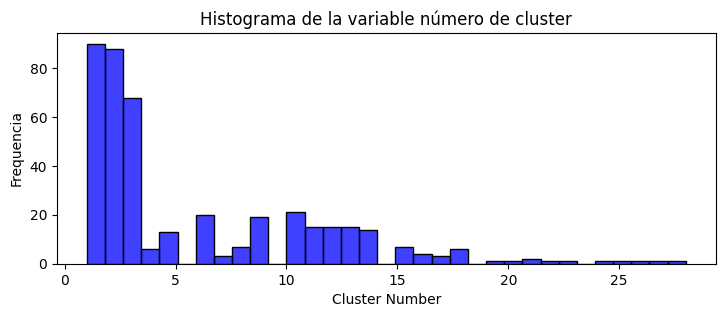

<IPython.core.display.Javascript object>

In [32]:
# Suponiendo que df_d ya está creado como en el código proporcionado
plt.figure(figsize=(8.5, 3))  # Ajuste el tamaño de la figura según sea necesario
sns.histplot(df_d['Cluster_number'], bins=33, color='b')  # kde=True agrega una estimación de densidad del kernel
plt.title('Histograma de la variable número de cluster')
plt.xlabel('Cluster Number')
plt.ylabel('Frequencia')

plt.show()
app_marker.run(port=8889)


# SPLITING

Aqui se dividen los datos en conjuntos de entrenamiento y prueba manteniendo la distribución de la actividad biológica en ambos grupos.

1.- Discretización de la Variable de Actividad: Convierte la variable continua de actividad (df_y) en categorías discretas

- n_bins=N_BINS: Divide el rango de actividades en N categorías

- strategy='uniform': Crea categorías de igual tamaño

2.- Creación del Splitter Estratificado:

- n_splits=N_SPLITS: Número de divisiones a generar

- test_size=TEST_SIZE: Porcentaje para test

- random_state=RANDOM_STATE: Para reproducibilidad

3.- Generación de la División: Crea los índices para entrenamiento y prueba

- split: Índices para entrenamiento

- split_test: Índices para prueba

4.- Asignación de Etiquetas

Marca cada molécula como 'train' o 'test'

In [33]:
# dividimos train test con stratified
discretizer = sklearn.preprocessing.KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="uniform")
splitter = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=RANDOM_STATE)
y_discrete = discretizer.fit_transform(df_data['Activity'].values.reshape(-1, 1))
split, split_test = next(splitter.split(df_x.values, y_discrete))
fractions = ["train" if i in split else "test" for i in range(df_data.shape[0])]
df_data = df_data.assign(fraction=fractions)
df_d = df_d.assign(fraction=fractions)

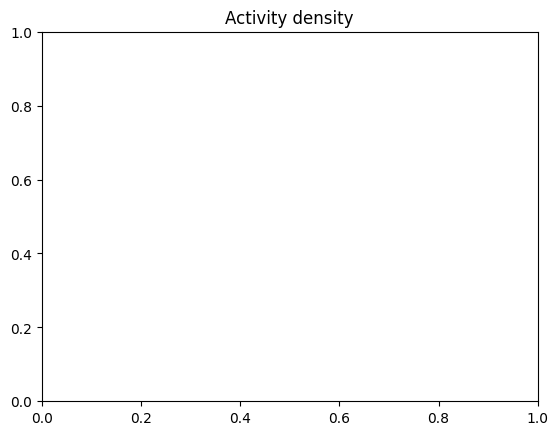

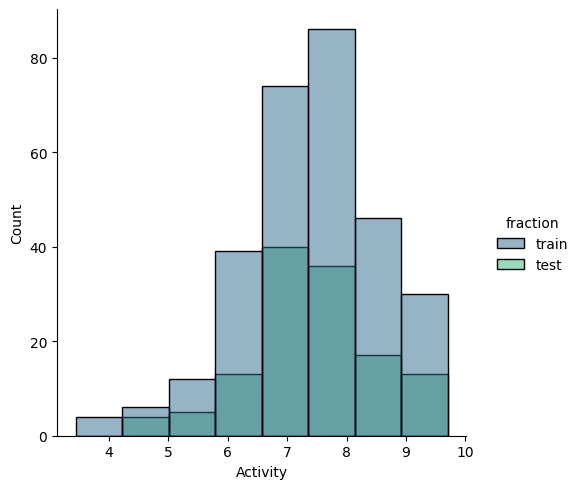

In [34]:
plt.title("Activity density")
sns.displot(data=df_data, x="Activity", hue="fraction", alpha=0.5, bins=8, palette="viridis") # Cambia la paleta de colores
plt.show()

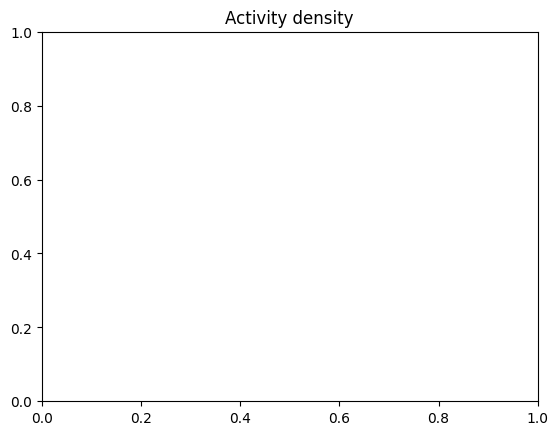

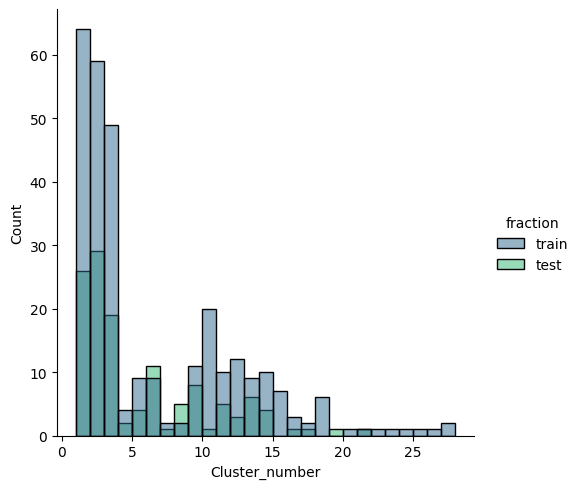

In [35]:
plt.title("Activity density")
sns.displot(data=df_d, x="Cluster_number", hue="fraction", alpha=0.5, bins=27, palette="viridis") # Cambia la paleta de colores s
#plt.show()

In [36]:
# @title
# sacamos los vectores (x, y) de interés
x_train = df_x[df_data["fraction"] == "train"].values
y_train = df_y[df_data["fraction"] == "train"].values
x_test = df_x[df_data["fraction"] == "test"].values
y_test = df_y[df_data["fraction"] == "test"].values
y_train = np.reshape(y_train, -1)
y_test = np.reshape(y_test, -1)

x_train = x_train.astype(float)
y_train = y_train.astype(float)
x_test = x_test.astype(float)
y_test = y_test.astype(float)

#x_train

# ENTRENAMIENTO


Se hace el preprocesamiento de los datos.

- Usa VarianceThreshold para eliminar descriptores con baja varianza, ya que no aportan información discriminativa al modelo.

- StandardScaler Estandariza los descriptores para evitar que descriptores con escalas grandes dominen el modelo.

- SelectFromModel se usa para la selección de características de 1018 descriptores, selecciona solo los 22 más importantes.

- PCA (Análisis de Componentes Principales) Reduce la dimensionalidad transformando los descriptores, de 22 descriptores seleccionados, crea 8 componentes principales.

Se crea el modelo final final y se entrena

In [37]:
# creamos pipeline: el modelo final final
steps = [
    ("var0", VarianceThreshold(MIN_VARIANCE)), #QUITA DESCRIPTORES CONSTANTES Y SEMICONSTANTES
    ("scaling", SCALER), #eSTANDARIZACIÓN
    ("feat_selector1", FEAT_SELECTOR1), #xg BOOST ASIGNA PESOS Y SELECTFORMMODEL USA ESOS PESOS PARA SLECCIONAR DESCRIPTORES
    ("feat_selector2", FEAT_SELECTOR2), #pca
    ("regressor", REGRESSOR) #svr
]
pipeline = Pipeline(steps, verbose=True)
pipeline = pipeline.fit(x_train, y_train)
pipeline.set_params(verbose=False)
pipeline

[Pipeline] .............. (step 1 of 5) Processing var0, total=   0.0s
[Pipeline] ........... (step 2 of 5) Processing scaling, total=   0.0s
[Pipeline] .... (step 3 of 5) Processing feat_selector1, total= 1.7min
[Pipeline] .... (step 4 of 5) Processing feat_selector2, total=   0.0s
[Pipeline] ......... (step 5 of 5) Processing regressor, total=   0.0s


Pipeline(steps=[('var0', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('feat_selector1',
                 SelectFromModel(estimator=XGBRegressor(base_score=None,
                                                        booster=None,
                                                        callbacks=None,
                                                        colsample_bylevel=None,
                                                        colsample_bynode=None,
                                                        colsample_bytree=0.8,
                                                        device=None,
                                                        early_stopping_rounds=None,
                                                        enable_categorical=True,
                                                        eval_metric=None,
                                                        feature_types=None...
                                                        learning_rate=0.2,
                                                        max_bin=None,
                                                        max_cat_threshold=None,
                                                        max_cat_to_onehot=None,
                                                        max_delta_step=None,
                                                        max_depth=8,
                                                        max_leaves=None,
                                                        min_child_weight=9,
                                                        missing=nan,
                                                        monotone_constraints=None,
                                                        multi_strategy=None,
                                                        n_estimators=1000,
                                                        n_jobs=None,
                                                        num_parallel_tree=None, ...),
                                 max_features=15)),
                ('feat_selector2', PCA(n_components=8, random_state=5712492)),
                ('regressor', SVR(C=4))])

In [38]:
# analizamos paso a paso las transformaciones
z = x_train
for (i, step) in enumerate(pipeline[:-1]):
    print(f"Step {pipeline.steps[i][0]} ({i}): {step.__class__.__name__}")
    print(f"  Input: {z.shape}. Output: {step.transform(z).shape}")
    z = step.transform(z)

Step var0 (0): VarianceThreshold
  Input: (297, 1423). Output: (297, 1237)
Step scaling (1): StandardScaler
  Input: (297, 1237). Output: (297, 1237)
Step feat_selector1 (2): SelectFromModel
  Input: (297, 1237). Output: (297, 15)
Step feat_selector2 (3): PCA
  Input: (297, 15). Output: (297, 8)


# VALIDACIÓN


- La bondad de ajuste se mide por el coeficiente de determinación ($r^{2}$)

- La robustez se refiere a la capacidad del modelo para realizar predicciones confiables de datos nuevos (no vistos)

- La predicción externa hace referencia a la calidad en la predicción obtenida por un conjunto de compuestos químicos que no fueron utilizados durante el desarrollo del modelo.

- Las métricas en la validación interna contienen ($r^{2}$) de la técnica Leave-Many-Out ($q^{2}_{CV-LMO}$) y la prueba de Y-Aleatorización (Y-Scrambling, en inglés)

- La validación externa tiene coeficientes $q^{2}_{ext}$

Se extraen los resultados y gráficas finales a reportar

In [ ]:
# @title
from tqdm import tqdm
df = pd.DataFrame()
for metric in tqdm(METRICS, desc="Summary"):
    df_ = validate_summary(metric)
    df = pd.concat([df, df_]) # Use pd.concat to combine DataFrames
round(df,2)

Summary: 100%|██████████| 2/2 [06:57<00:00, 208.65s/it]


,train,cv,test
r2,0.81,0.58,0.70
neg_mean_squared_error,-0.24,-0.52,-0.35


# DOMINIO DE APLICACIÓN



Se define como una región teórica dentro del espacio químico determinado por los descriptores empleados para construir el modelo QSAR, nos indica donde se puede usar el modelo de forma confiable.

##Preparación de datos

In [39]:
# Primero entrena a los modelos de dominio de aplicación
transformer = pipeline[:-1] #Ccrea una nueva variable transformer. A esta variable se le asigna al útltimo paso del pipeline.

In [40]:
# @title
#Entrenamiento de los modelos del Dominio de Aplicabilidad (AD). que estiman la fiabilidad de las predicciones
for model in APP_DOMAINS:
    z_train = transformer.transform(x_train)
    model = model.fit(z_train)
print("Numero de features después de las reducciones:", z_train.shape[0])
APP_DOMAINS

Numero de features después de las reducciones: 297


[LeverageMethod()]

In [41]:
# @title
# Guardemos los resultados del modelo de DA en un nuevo dataframe, para poder manipular los datos con mayor facilidad.
# Creamos un Dataframe vacío para guardar los resultados.
results_da = pd.DataFrame()

# Se ejecuta para modelo definido en APP_DOMAINS
for model in APP_DOMAINS:
    # Invoca a la función validate_domain para obtener del Dataframe de cada modelo
    df_model = validate_domain(model)
    # Agrega una columna para identificar el modelo
    df_model['Model'] = mname(model)

    # Concatenar el DataFrame de cada modela DA con el DataFrame de resultados_df
    results_da = pd.concat([results_da, df_model])

# Restablecer el índice al índice original desde df_data
results_da = results_da.set_index(df_data.index)
# Fusionar df_info con results_df según su índice común
results_da = pd.merge(df_info, results_da, left_index=True, right_index=True)

# Ahora results_df contiene los residuos y las puntuaciones de todos los modelos y del índice original.
# Puede procesar o analizar este DataFrame según sea necesario.
#results_df

/tmp/ipykernel_3943/1021448078.py:13: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [42]:
for model in APP_DOMAINS:
    validate_domain(model)

/tmp/ipykernel_3943/1021448078.py:13: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [43]:
# En este nuevo dataframe agregaremos la información del cluster
#df_info = data[['Cmpd','SMILES']].copy() # Seleccionamos algunas columnas desde data
#df_info['Cluster_number'] = cluster_id

In [44]:
# @title
# Añadimos tres columna que nos permitirá visualizar la información de los clusters con plotly
results_da['fraction1'] = results_da['fraction'].astype('category').cat.codes
results_da['cn'] = results_da['Cluster_number'].astype('category').cat.codes
results_da['cn_s'] = 'Cluster ' + results_da['Cluster_number'].astype(str)
results_da = results_da.assign(Activity=df_data['Activity'])

In [45]:
# @title
# Crear DA_data DataFrame
DA_data = results_da[['Cmpd', 'SMILES', 'Score','Cluster_number']].copy()
DA_data = DA_data.rename(columns={'Score': 'LeverageMethod_domain'})
#DA_data

## Apalancamiento

Se muestra el diagrama de Williams en el cual se grafica residuales estandarizados vs apalancamiento, donde los valores por encima de Hmax son aquellos donde la confianza disminuye y aquellos valores por debajo de Hmax son predicciones con mayor confianza, este último es la llamada zona segura = predicciones confiables.

In [46]:
results_da

,Cmpd,SMILES,Cluster_number,Score,Residual,fraction,Model,fraction1,cn,cn_s,Activity
0,6a,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=CC=C3,13,0.085170,0.100453,train,LeverageMethod,1,12,Cluster 13,5.080922
1,6b,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OC3=CC=C(C(C)=O)C=...,13,-0.015973,-0.361177,train,LeverageMethod,1,12,Cluster 13,6.124939
2,6c,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCCC3=CNN=C3)C=C2)...,13,-0.042221,0.099804,train,LeverageMethod,1,12,Cluster 13,5.161151
3,6d,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCC)C=C2)SC=C1C3=C...,13,-0.028833,0.100046,train,LeverageMethod,1,12,Cluster 13,6.167491
4,6e,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=C(O...,13,-0.050741,0.344683,train,LeverageMethod,1,12,Cluster 13,5.723538
...,...,...,...,...,...,...,...,...,...,...,...
420,64f,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,-0.030862,-0.321411,test,LeverageMethod,0,0,Cluster 1,8.301030
421,64g,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,-0.036946,-0.442899,test,LeverageMethod,0,0,Cluster 1,7.481486
422,64h,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,-0.023775,-0.100263,test,LeverageMethod,0,0,Cluster 1,7.853872
423,64i,O=C(NC1=CC=C(F)C([C@]2(C)CO[C@@](C)(C(F)(F)F)C...,1,-0.030083,0.439335,test,LeverageMethod,0,0,Cluster 1,7.795880


In [47]:
# @title
#________________Por si se enciman los datos_________________________________
a = results_da.copy()
#a = results_da[results_da['fraction1'].isin([0,1,2])]
#a = results_da[results_da['Cluster_number'].isin([2,1])] # que clusters seleccionamos
#________________Definimos la gráfica______________________________
# Crea una matriz de dispersión con Plotly

fig = px.scatter(a, x="Score", y="Residual",
                 #____color______________________
                #  color="Cluster_number",
                 #color="Activity",
                 color ='fraction',
                 #____color______________________
                 title="Residuales vs. Puntaje de apalancamiento",
                 labels={'Score': 'Puntuación','train': 'Entrenamiento', 'test':'Prueba'},
                 width = 900, height=500)

fig.add_vline(x=0, line_width=3, line_color="green")
fig.update_layout(    plot_bgcolor="white",  # Set plot background color
paper_bgcolor="white"   # Set paper background color
                          )
fig.add_hline(y=1, line_width=1, line_dash="dash", line_color="green")
fig.add_hline(y=0, line_width=1, line_color="black")
fig.add_hline(y=-1, line_width=1, line_dash="dash", line_color="green")
# fig.add_hline(y=0.5, line_width=1, line_dash="dash", line_color="green")
# fig.add_hline(y=-0.5, line_width=1, line_dash="dash", line_color="green")

# Set background color to white
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
#fig.update_layout(legend=dict(font=dict(size=10)))  # Increase legend font size
#fig.update_layout(font=dict(size=8)) # Increase font size for all text elements
fig.update_layout(hoverlabel_font_size=20)
#fig.update_layout(showlegend=False) # This line removes the legend
#fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="right", x=0))
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig.update_traces(marker=dict(size=12)) # Increase marker size

app_marker1 = molplotly.add_molecules(fig=fig,
                                      df=a,
                                      smiles_col='SMILES',
                                     # title_col='Cmpd',
                                      #_______color____________________________
                                      #color_col='Activity',
                                      # color_col='Cluster_number',
                                      #color_col='fraction',
                                      color_col='fraction',
                                      #________________________________________
                                      fontsize=15, width=350,
                                      caption_cols=['Cluster_number','Activity'])
app_marker1.run(port=8772)
#fig.show()

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [48]:
# Guardamos la información del domino de aplicación en un dataframe llamado standardized_residuals_df
std_residuals = standardize_residuals(APP_DOMAINS[0])

# Fusiona df_info con standardized_residuals_df según su índice común.
std_residuals= std_residuals.set_index(df_data.index)
std_residuals_ = pd.merge(df_info, std_residuals, left_index=True, right_index=True)

/tmp/ipykernel_3943/2392347869.py:17: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [49]:
# @title


#___________________________________________________________________________________________
### Gráfica "Standardized_Residual vs. Leverage Score"
#________________Por si se enciman los datos_________________________________
a = std_residuals_.copy()
#a = std_residuals[std_residuals['fraction1'].isin([0,1,2])]
#a = std_residuals[std_residuals['Cluster_number'].isin([2,1])] # que clusters seleccionamos
#________________Definimos la gráfica______________________________

fig = px.scatter(a, x="Score", y="Standardized_Residual",
                 color="fraction",
                #  color="Cluster_number",
                 #facet_col="Model",
                 title="Residuos estandarizados vs. Puntuación de apalancamiento",
                 labels={'Score': 'Puntuación','train': 'Entrenamiento', 'test':'Prueba','Standardized_Residual': 'Residuales estandarizados'},
                 width=900,height=500)
#____Formateo_____________________________________________________________________
# Set background color to white
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
#fig.update_layout(legend=dict(font=dict(size=10)))  # Increase legend font size
#fig.update_layout(font=dict(size=8)) # Increase font size for all text elements
fig.update_layout(hoverlabel_font_size=20)
#fig.update_layout(showlegend=False) # This line removes the legend
#fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="right", x=0))
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig.update_traces(marker=dict(size=12)) # Increase marker size
#____respecto a linea_____________________________________________________________
fig.add_vline(x=0, line_width=3, line_color="green")
#fig.add_hline(y=2, line_width=1, line_dash="dash", line_color="green")
fig.add_hline(y=0, line_width=1, line_color="black")
#fig.add_hline(y=-2, line_width=1, line_dash="dash", line_color="green")
fig.add_hline(y=1, line_width=1, line_dash="dash", line_color="green")
fig.add_hline(y=-1, line_width=1, line_dash="dash", line_color="green")
#_______________________________________________________________________________
app_marker2 = molplotly.add_molecules(fig=fig, df=a,
                                     smiles_col='SMILES',
                                     #title_col='Cmpd',
                                     color_col='fraction',
                                      # color_col='Cluster_number',
                                     caption_cols=['Cluster_number'],
                                     fontsize=10, width=210)

app_marker2.run(port=8773)
#fig.show()

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

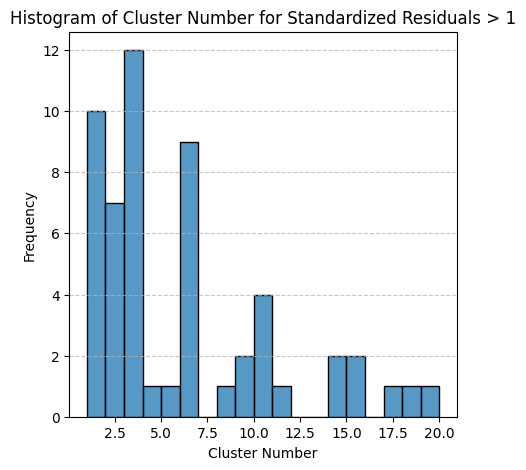

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for Standardized_Residual > 1
filtered_std_residuals = std_residuals_[std_residuals_['Standardized_Residual'] > 1]

# Create the histogram
plt.figure(figsize=(5, 5))
sns.histplot(data=filtered_std_residuals, x='Cluster_number',
             #bins=len(filtered_std_residuals['Cluster_number'].unique()), kde=False
             bins=19
             )
plt.title('Histogram of Cluster Number for Standardized Residuals > 1')
plt.xlabel('Cluster Number')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

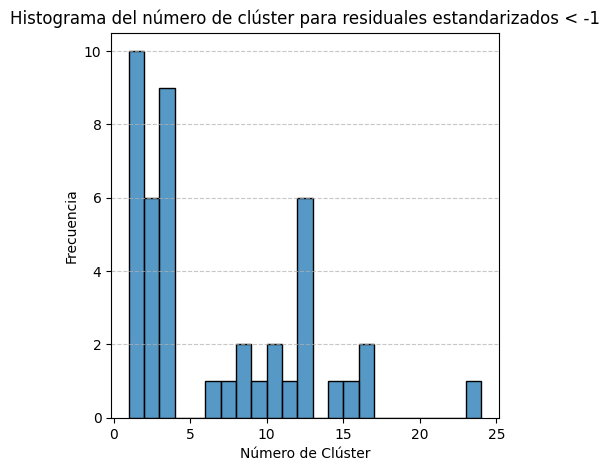

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para Standardized_Residual < -1
filtered_std_residuals_below_neg1 = std_residuals_[std_residuals_['Standardized_Residual'] < -1]

# Crear el histograma
plt.figure(figsize=(5, 5))
sns.histplot(data=filtered_std_residuals_below_neg1, x='Cluster_number',
             bins=23
             )
plt.title('Histograma del número de clúster para residuales estandarizados < -1')
plt.xlabel('Número de Clúster')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [52]:
filtered_std_residuals_below_neg1.shape #residuos menores a -1
filtered_std_residuals.shape #Residuos mayores a 1

(55, 6)

In [53]:
import plotly.express as px
import molplotly

# Definir los clústeres de interés
clusters_of_interest = [1, 2, 3, 6]

# Filtrar el DataFrame `std_residuals_` para los clústeres seleccionados
filtered_clusters = std_residuals_[std_residuals_['Cluster_number'].isin(clusters_of_interest)].copy()

# Es necesario que `Activity` esté en este DataFrame para el gráfico.
# Dado que `std_residuals_` se creó fusionando `df_info` con `std_residuals`, y `df_info`
# no contiene `Activity`, necesitamos fusionar `std_residuals_` con `df_y`.
# Voy a asumir que `df_y` es el DataFrame original que contiene la columna 'Activity'.
# Si `std_residuals_` ya contiene 'Activity', esta línea no será estrictamente necesaria,
# pero es una medida de seguridad para asegurar que 'Activity' esté presente.
std_residuals_with_activity = pd.merge(filtered_clusters, df_y, left_index=True, right_index=True, how='left')

# Crear el gráfico de dispersión
fig = px.scatter(std_residuals_with_activity,
                 x="Standardized_Residual",
                 y="Activity",
                 color="Cluster_number", # Color por número de clúster
                 color_discrete_sequence=px.colors.qualitative.Dark24, # Asegura colores distintos para cada clúster
                 title="Actividad vs. Residuales por Clúster", #(Clústeres 1, 2, 3, 6)",
                 labels={
                     "Standardized_Residual": "Residual Estandarizado",
                     "Activity": "Actividad",
                     "Cluster_number": "Cluster"
                        },
                 width=500, height=500)

# Personalizar el diseño del gráfico
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    hoverlabel_font_size=16
)

# Personalizar los marcadores
fig.update_traces(
    marker=dict(line=dict(width=1, color='Black'), size=10)
)

# Añadir interactividad con molplotly
app_scatter_activity_res = molplotly.add_molecules(
    fig=fig,
    df=std_residuals_with_activity,
    smiles_col='SMILES',
    color_col='Cluster_number',
    caption_cols=['Cmpd', 'Activity', 'Standardized_Residual', 'Cluster_number'],
    fontsize=14, width=250
)

app_marker3 = molplotly.add_molecules(fig=fig, df=a,
                                     smiles_col='SMILES',
                                     #title_col='Cmpd',
                                     color_col='fraction',
                                      # color_col='Cluster_number',
                                     caption_cols=['Cluster_number'],
                                     fontsize=10, width=210)
# Ejecutar la aplicación molplotly
#app_scatter_activity_res.run(port=8720)
app_marker3.run(port=8773)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

# Experimental vs Predicción



Muestra la correlación entre los valores experimentales y los predichos, de esta manera aseguramos la precisión del modelo.

In [54]:
# @title
df_pve = df_info.assign(Experimental=df_y, Predicted=pipeline.predict(df_x))
# Suponiendo que df_info y df_y tienen un índice común
df_combin = pd.concat([df_pve, df_d['fraction']], axis=1)
# Ordena df_combin con Cluster_number de manera asecendente
df_combin = df_combin.sort_values(by='Cluster_number', ascending=True)
df_combin['cn_s'] = 'Cluster ' + df_combin['Cluster_number'].astype(str)
# Crear una asignación de valores de Cluster_number a valores numéricos

#___Creamos con plotly una grafica de experimental vs predicted con df_combined_______________________________________
fig = px.scatter(df_combin, x="Experimental", y="Predicted",
                 #__color_______________________________________
                 color= 'fraction',
                #  color = 'cn_s',
                 #color="Cluster_number",
                 #______________________________________________
                 title="Experimental vs Predicho",
                 #symbol="fraction",
                 width=800,height=550)

fig.add_shape(type="line", line=dict(dash='dash'),
              x0=df_combin["Experimental"].min(), y0=df_combin["Experimental"].min(),
              x1=df_combin["Experimental"].max(), y1=df_combin["Experimental"].max())

fig.update_layout(plot_bgcolor="white",  # Set plot background color
                  paper_bgcolor="white")   # Set paper background color
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig.update_traces(marker=dict(size=12)) # Increase marker size
fig.update_layout(hoverlabel_font_size=20)

app_marker = molplotly.add_molecules(fig=fig,
                                     df=df_combin,
                                     smiles_col='SMILES',
                                     color_col='fraction',
                                    #  color_col= 'cn_s',
                                     caption_cols=['Cmpd','Cluster_number'],
                                     fontsize=15, width=220)

app_marker.run(port=8774)
#fig.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but VarianceThreshold was fitted without feature names

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

## Y Scramble

Muestra la prueba de Y-Aleatorización que muestra la correlación entre los valores experimentales y los predichos, de esta manera aseguramos precisión del modelo y que este mismo no fue producto del azar

In [55]:
#validate_yscramble()

# EXPLORACIÓN

Predicción de actividad de las nuevas moléculas

## Definimos al grupo xplor


Este grupo contiene dos conjuntos de moléculas, uno se obtiene a partir de diccionarios y otro a partir de un excel que se aloja en ggogle drive. Este último lo llamaremos mediante `! gdown -- id  ` y la funcion `pd.read_excel()`

___________________________
___________________________
___________________________
a) xplor

se puede definir a partir de diccionarios como smiles_dict que contiene las moléculas nuevas de las que queremos predecir su actividad biológica. En caso de usar el diccionario es necesario que la variable SMILES_LIST = True. La idea es que se use el diccionario para hacer predicciones rápidas de grupos pequeños de moléculas

Cada entrada es:

clave: nombre asignado a la molécula

valor: el SMILES, que es la representación lineal de su estructura química

Estos SMILES se usarán como grupo de exploración (xplor), es decir, como las moléculas que se evaluarán con el modelo QSAR para predecir actividad.


Para grandes grupos de moléculas se vuelve complicado usar un diccionario, y por lo regular sulen usarse archivos excel o csv, que contienen una columna con un identificador ('Cmpd') y el SMILE correspondiente. En este caso dicho archivo se importa desde drive con `!gdown --id `y se define el dataframe con pandas. para usar un archivo Excel o CSV es necesario que `excel = True`, y definir el ID del documento y su nombre con la función de `pd.read_excel()`


_____________________________
_____________________________
_____________________________

b) commercial_drugs

Este diccionario contiene moléculas comerciales conocidas. Compara resultados de predicción entre tus moléculas nuevas desconocidas y las comerciales conocidas, a traves de la representación del espacio quíico y el domino de aplicación.

Este grupo commercial_drugs NO entrena el modelo, sino que sirve para comparar moléculas conocidas o usadas comercialmente, en cuanto a predicciones y propiedades.

El modelo QSAR posteriormente usa el grupo xplor para:

- Leer sus SMILES

- Calcula sus descriptores moleculares

- Predice las propiedad de interés (actividad, logP, pIC50, etc) y dominio de aplicación

- Hace representación del espacio químico

In [56]:
excel = True
SMILES_LIST = False
comercial = True

In [57]:
smiles_dict = {
    '51': 'FC(F)OC1=CC=C([C@@]2(C3=CC(/C(F)=C\C4CC4)=CC=C3)C(N(C)C(N)=N2)=O)C=C1',
    '46': 'CC1=CC=CC=C1C2=CC3=C(C=C2)N=C(N)C(C[C@@H](C)C(NCC4CCCCC4)=O)=C3',
    '12': 'NC1=N[C@@](C2=CC(NC(C3=NC=C(C#N)C=C3)=O)=CC=C2F)(C)C(C)=CO1'
              }
comercial_drugs = {
    'Donepecilo': 'O=C1C(CC2CCN(CC3=CC=CC=C3)CC2)CC4=CC(OC)=C(OC)C=C41',
    'Galantamina': 'O[C@@H]1C[C@H]2[C@]3(C(C(O2)=C(OC)C=C4)=C4CN(C)CC3)C=C1',
    'mamantadina': 'NC1C2CC(CC1CC3)CC3C2',
    'rivastigmina': 'CCN(C)C(OC1=CC([C@H](C)N(C)C)=CC=C1)=O'
                  }

<>:2: SyntaxWarning:

invalid escape sequence '\C'

<>:2: SyntaxWarning:

invalid escape sequence '\C'

/tmp/ipykernel_3943/1457922079.py:2: SyntaxWarning:

invalid escape sequence '\C'



In [58]:
# @title
xplor = pd.DataFrame()
if excel is True:

  #____DEBES DEFINIR ID Y NOMBRE DEL ARCHIVO EXCEL
  # El archivo EXCEL SOLO DEBE TENER DOS columnas: 'SMILES' y 'Cmpd'

  # !gdown --id 1C4MQVLvAIYwBv1FJ-zzcJ6c91AuwdXyH #IMPORTANTE____Original
  # excel = pd.read_excel("NPDIFACQUIM.xlsx") #IMPORTANTE

 # excel = df_info
  # !gdown --id 1xJlMEy_h5xkBKeVmC9lWuYrEPJx_hFxx
  # excel = pd.read_excel("L9_SMILES.xlsx")
  #________________________________________________
  #! gdown --id 1_vE6EPXJYAiPR1g6kBl2uE5u_-aJ1oft
  #xplor = pd.read_excel("drugs.xlsx")
  #______________________________________
  #______________________________________________
  #Grupo de exploración basado en Cluster 10
  # !gdown --id 1kde4LJLar_s3As7FGvHMpH5lGMw5I5RD
  # excel = pd.read_excel("Cluster10_Manuel.xlsx")

  #______________________________________
  # #______________________________________________
  # #Grupo de exploración basado en Molecula 440
  # !gdown --id 112kRALh152GjRapQOBZOlseQIXtXBWDb
  # excel = pd.read_excel("Manuel_440Sus.xlsx")

  #______________________________________
  #______________________________________________
  # #Grupo de exploración basado en Molecula 440_V1.0
  # !gdown --id 1M7c8B0-xvx2P6nNdnjcjuGuG7hSXzH0_
  # excel = pd.read_excel("Manuel440_1.0.xlsx")

  #______________________________________
  #______________________________________________
  # #Grupo de exploración NewManuelDB
  !gdown --id 1mAG2wlElrYH3r97g8SNLvm6-3PNkZ9G7
  excel = pd.read_excel("NewManuelDB.xlsx")



  excel['G'] = 'xplor'
  excel['Cluster_number'] = len(set(cluster_id))+1
  xplor = pd.concat([xplor, excel], ignore_index=True)
  print('Un archivo excel se adicionó a xplor')
else:
    print('NO se proceso EXCEL para adicionar a xplor')


if SMILES_LIST is True:
  #convierte smiles_dict en un dataframe
  sl = pd.DataFrame(list(smiles_dict.items()), columns=['Cmpd', 'SMILES'])
  sl['G'] = 'xplor'
  sl['Cluster_number'] = len(set(cluster_id))+1
  xplor = pd.concat([xplor, sl], ignore_index=True)
  print('Un diccionario con SMILES se adicionó a xplor')
else:
  print('NO se proceso el DICCIONARIO para adicionar a xplor')

if comercial is True:
  #convierte comercial_drugs en un dataframe
  com_drugs = pd.DataFrame(list(comercial_drugs.items()), columns=['Cmpd', 'SMILES'])
  com_drugs['G'] = 'comercial'
  com_drugs['Cluster_number'] = len(set(cluster_id))+2
  xplor = pd.concat([xplor, com_drugs], ignore_index=True)
  print('Los fármacos comerciales se tomaran en cuenta')
else:
  print('NO se tomaran en cuenta los fármacos comerciales')

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1mAG2wlElrYH3r97g8SNLvm6-3PNkZ9G7
To: /content/NewManuelDB.xlsx
100% 11.0k/11.0k [00:00<00:00, 20.4MB/s]
Un archivo excel se adicionó a xplor
NO se proceso el DICCIONARIO para adicionar a xplor
Los fármacos comerciales se tomaran en cuenta


## Descriptores, predicción y modelos DA

In [59]:
import numpy as np

# Create a temporary 'mol_check' column to convert SMILES to RDKit molecules.
# Convert each SMILES entry to string type to handle potential float/NaN values,
# then attempt to create an RDKit molecule. Invalid SMILES will result in None.
xplor_temp = xplor.copy()
xplor_temp['mol_check'] = xplor_temp['SMILES'].apply(lambda x: Chem.MolFromSmiles(str(x)) if pd.notna(x) else None)

# Filter out rows where 'mol_check' is None (indicating an invalid or missing SMILES)
# and drop the temporary 'mol_check' column.
xplor_filtered = xplor_temp[xplor_temp['mol_check'].notna()].drop(columns=['mol_check'])

# Calculate Mordred descriptors using the filtered and validated SMILES.
mordred_descriptors = All_Mordred_descriptors(xplor_filtered['SMILES'])

# Concatenate the filtered xplor DataFrame with the calculated Mordred descriptors.
# Reset the index of xplor_filtered to ensure proper alignment during concatenation
# after potentially dropping rows.
xplor_mordred = pd.concat([xplor_filtered.reset_index(drop=True), mordred_descriptors], axis=1)

100%|██████████| 169/169 [00:36<00:00,  4.63it/s]


In [60]:
# @title
# Seleccionar solo las características que estaban incluídas en el dataframe incial data
# Esta información adicional será guardada en una variable llamada df_val, con la que trabaja el pipeline
names = xplor_mordred["Cmpd"]
df_val = xplor_mordred[df_x.columns] #Esta variable entra al pipeline
df_val = df_val.dropna()# Quita las filas que tienen NaN elementos
# Imputar valores faltantes utilizando la media
imputer = SimpleImputer(strategy='mean') # O utilice otras estrategias como 'mediana', 'más_frecuente'
df_val = pd.DataFrame(imputer.fit_transform(df_val), columns=df_val.columns, index=df_val.index)
df_val.shape

(169, 1423)

In [61]:
# str(list(df_val.columns))

In [62]:
#filtramos los datos por PC
# filtered_dataset1 = df_val.copy()
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['MW'] <= 450]
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['BalabanJ'] <= 2.9]
# # filtered_dataset1 = filtered_dataset1[filtered_dataset1['BalabanJ'] >= 1.4]
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA1'] <= 21]
# filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA10'] <= 24]
# # filtered_dataset1 = filtered_dataset1[filtered_dataset1['PEOE_VSA13'] <= 12]
# df_val = filtered_dataset1.copy()
# df_val.shape

In [63]:
# @title
# Calculamos los valores de predicción y DA para el grupo de exploración, los guardamos en df
# es decir los valores de las nuevas moléculas a predecir o explorar.
df = pd.DataFrame({"pred": pipeline.predict(df_val.values)}, index=names) #pipeline.predict(df_val.values)} aplica toda la pipeline a df_val
for model in APP_DOMAINS:
    Score = model.decision_function(pipeline[:-1].transform(df_val.values))
    df[f"{mname(model)}_domain"] = Score
#df

In [64]:
# @title
# prompt: a df_v asignale indices
xplor_pred = df.reset_index()
xplor_pred = xplor_pred.drop(columns=['Cmpd'])
#xplor_pred['Cluster_number'] = xplor_mordred['Cluster_number']
# Concatenate xplor and df_v DataFrames
xplor_pred = pd.concat([xplor, xplor_pred], axis=1)

In [65]:
xplor_pred

,Cmpd,SMILES,G,Cluster_number,pred,LeverageMethod_domain
0,1,NC1=NC(CCC(NC)=O)=CC=C1,xplor,29,6.388202,0.129663
1,2,NC1=NC(CCC(NO)=O)=CC=C1,xplor,29,6.355079,0.139288
2,3,NC1=NC(CCC(NO)=O)=CC2=C1CCCC2,xplor,29,4.999627,0.019474
3,4,NC1=NC(CCC(NO)=O)=CC2=C1C=CC=C2,xplor,29,5.063579,0.008145
4,5,NC1=NC(CCC(NN)=O)=CC=C1,xplor,29,6.365461,0.129856
...,...,...,...,...,...,...
164,NaN,O=C(N1C2CC(C1)NC2)CCC3=CC=CN=C3N,xplor,29,5.003453,-0.017672
165,Donepecilo,O=C1C(CC2CCN(CC3=CC=CC=C3)CC2)CC4=CC(OC)=C(OC)...,comercial,30,5.645154,-0.059374
166,Galantamina,O[C@@H]1C[C@H]2[C@]3(C(C(O2)=C(OC)C=C4)=C4CN(C...,comercial,30,5.726850,-0.038357
167,mamantadina,NC1C2CC(CC1CC3)CC3C2,comercial,30,6.450571,0.199273


# PREDICCIONES

In [66]:
#definimos el umbral
da_limit = 0  #Eje x
Activity_limit = 8 #Eje y

In [67]:
# Creamos uan gráfica de valores predichos respecto al Dominio de Aplicación
fig = px.scatter(xplor_pred, x="LeverageMethod_domain", y="pred",
                 title="LeverageMethod_domain vs pred",
                 width= 500,height = 500)

#___________Respecto a la linea_________________________________________________
fig.add_vline(x=0, line_width=3, line_color="green")
fig.add_hline(y=Activity_limit, line_width=3, line_color="green")

fig.update_layout(plot_bgcolor="white",  # Establecer color de fondo
                  paper_bgcolor="white")   # Establecer el color de fondo del papel
#___________Respecto al formato_________________________________________________
app_marker = molplotly.add_molecules(fig=fig,
                                     df=xplor_pred,
                                     smiles_col='SMILES',
                                    # title_col='Cmpd',
                                     #color_col='fraction',
                                     caption_cols=['Cmpd'],
                                     fontsize=15,
                                     width=220)
app_marker.run(port=8775)
#fig.show()

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [68]:
test_smiles_df_ = results_da[results_da['fraction'] == 'test']
df_selected_smiles_activity = test_smiles_df_.iloc[[1, 11, 21]][['SMILES', 'Activity']]
print(df_selected_smiles_activity)

                                                SMILES  Activity
298  NC1=NC(C2=CC=C([H])C=C2)(C3=NCCCN31)C4=CC(OC)=...  4.692504
308  NC1=N[C@@](C2=CC=C(OC(F)(F)F)C=C2)(C3=NCCCN31)...  7.468521
318  NC1=NC(C2=CC=C(OC(F)(F)F)C=C2)(C3=NCCN31)C4=CC...  7.096910


### filtracion

In [69]:
# Vamos a utiliza un umbral para filtrar los valores con leverage mayor que 0 y con valor predicted mayor a 5.2
filtered = xplor_pred[(xplor_pred['LeverageMethod_domain'] < da_limit
                       ) & (xplor_pred['pred'] > Activity_limit
                            )]
filtered.shape

(15, 6)

In [70]:

#____________________________________________________________________________
# Graficamos la información filtrada
fig = px.scatter(filtered, x="LeverageMethod_domain", y="pred",
                 title="LeverageMethod_domain vs pred",
                 width= 600,height = 600)
#___________Respecto a la linea_________________________________________________
fig.add_vline(x=0, line_width=3, line_color="green")
fig.add_hline(y=Activity_limit, line_width=3, line_color="green")
fig.update_layout(plot_bgcolor="white",  # Set plot background color
    paper_bgcolor="white")   # Set paper background color
#_____________________________________________________________________________
app_marker = molplotly.add_molecules(fig=fig,
                                      df=filtered,
                                      smiles_col='SMILES',
                                    caption_cols=['Cmpd', 'G'],
                                      fontsize=15, width=300
                                     )

app_marker.run(port=8776)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [71]:
save=True
if save is True:
  XPLOR = filtered[['pred',	'Cmpd',	'SMILES',	'G']]
  XPLOR = filtered.rename(columns={'pred': 'Activity'})
  XPLOR.to_excel('XPLOR_1.xlsx', index=False)
  print('SE guardó XPLOR')
else:
  print('No se guardó XPLOR')

SE guardó XPLOR


# ESPACIO QUÍMICO



El espacio químico es un concepto fundamental en quimioinformática, es asociado con el conjunto de todas las moléculas posibles, que están descritas por un espacio multidimensional que representa propiedades estructurales, así como funcionales y su relación entre las moléculas molecular.

Se hace uso de dos tipos de representaciones

1.- Por PCA (Análisis de componentes principales)


2.- Por T-SNE,  (t-Distributed Stochastic Neighbor Embedding, por sus siglas en inglés) o Incrustación de vecinos estocásticos distribuidos en t.

Los descriptores que se representan en el espacio químico son

### Espacio químico descriptores

In [73]:
DATA_xplor = filtered.copy()
DATA_data = df_info.copy()
# prompt: combina DATA_data con df_y
DATA_data = pd.concat([DATA_data, df_y], axis=1)

In [74]:
# Generar descriptores
DATA_data["HBA"] = [Descriptors.NumHAcceptors(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
DATA_data["HBD"] = [Descriptors.NumHDonors(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
DATA_data["RB"] = [Descriptors.NumRotatableBonds(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
#DATA_data["RB"] = [Descriptors.MinPartialCharge(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
DATA_data["LogP"] = [Descriptors.MolLogP(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
DATA_data["TPSA"] = [Descriptors.TPSA(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]
DATA_data["MW"] = [Descriptors.MolWt(y) for y in (Chem.MolFromSmiles(x) for x in DATA_data["SMILES"])]

In [75]:
# Generar descriptores
DATA_xplor["HBA"] = [Descriptors.NumHAcceptors(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
DATA_xplor["HBD"] = [Descriptors.NumHDonors(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
DATA_xplor["RB"] = [Descriptors.NumRotatableBonds(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
#DATA_xplor["RB"] = [Descriptors.MinPartialCharge(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
DATA_xplor["LogP"] = [Descriptors.MolLogP(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
DATA_xplor["TPSA"] = [Descriptors.TPSA(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]
DATA_xplor["MW"] = [Descriptors.MolWt(y) for y in (Chem.MolFromSmiles(x) for x in DATA_xplor["SMILES"])]

In [76]:
chemspace_data = DATA_data.copy()
#A chemspace_data agrega una columna llada G , que tenga el valor 'data' para todos los elementos
chemspace_data['G'] = 'data'
# Fusionar chemspace_data con DA_data según la columna 'Cmpd'
chemspace_data = pd.merge(chemspace_data, DA_data[['Cmpd', 'LeverageMethod_domain']], on='Cmpd', how='left')
# Now chemspace_data contains the 'LeverageMethod_domain' column from DA_data.
#chemspace_data

In [77]:
chemspace_xplor = DATA_xplor.copy()
# prompt: en chemspace_xplor elimina las columnas: ZIN_ID, G, Component1, Component2, Component3
chemspace_xplor = chemspace_xplor.drop(columns=['ZINC_ID', 'component1', 'component2', 'component3'], errors='ignore')
# prompt: en chemspace_xplor cambia el nombre de la columna 'pred' por 'Activity'
chemspace_xplor = chemspace_xplor.rename(columns={'pred': 'Activity'})
# prompt: agrega la columna G a chemspace_xplor

#chemspace_xplor['G'] = 'comb'
#chemspace_xplor['Cluster_number'] = int(len(set(cluster_id))+1)

In [78]:
# Concatenar a lo largo de filas (eje=0)
chemspace = pd.concat([chemspace_data, chemspace_xplor], axis=0, ignore_index=True)

# Si es necesario, puede restablecer el índice:
# chemspace = chemspace.reset_index()

# A chemspace, agrega, una columna que se llame G2, que tenga valores numéricos para cada valor de G, esto servira mása adelante para visualizar datos en molplotly
# Crear un mapeo de valores 'G' a valores numéricos
g_mapping = {'data': 1, 'xplor': 2, 'comb': 3}  # Example mapping
# Cree la columna 'G2' en función del mapeo
chemspace['G2'] = chemspace['G'].map(g_mapping)
# Añadimos una columna que nos permitirá visualizar la información de los clusters con plotly

chemspace['cn_s'] = 'Cluster ' + chemspace['Cluster_number'].astype(str)
# Crear una asignación de valores de Cluster_number a valores numéricos
cluster_mapping = {cluster: i + 1 for i, cluster in enumerate(sorted(chemspace['Cluster_number'].unique()))}
# Crea la columna 'cn' en función del mapeo
chemspace['cn'] = chemspace['Cluster_number'].map(cluster_mapping)

In [79]:
chemspace

,Cmpd,SMILES,Cluster_number,Activity,HBA,HBD,RB,LogP,TPSA,MW,G,LeverageMethod_domain,G2,cn_s,cn
0,6a,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=CC=C3,13,5.080922,2,2,4,3.42460,81.47,335.432,data,0.085170,1,Cluster 13,13
1,6b,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OC3=CC=C(C(C)=O)C=...,13,6.124939,4,2,7,6.07290,107.77,504.011,data,-0.015973,1,Cluster 13,13
2,6c,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCCC3=CNN=C3)C=C2)...,13,5.161151,4,3,8,4.42260,119.38,479.993,data,-0.042221,1,Cluster 13,13
3,6d,O=C(/N=C(N)/N)CC1=C(C2=CC=C(OCC)C=C2)SC=C1C3=C...,13,6.167491,3,2,6,3.82330,90.70,379.485,data,-0.028833,1,Cluster 13,13
4,6e,O=C(/N=C(N)/N)CC1=C(C2=CC=CC=C2)SC=C1C3=CC=C(O...,13,5.723538,3,2,7,4.21340,90.70,393.512,data,-0.050741,1,Cluster 13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2197,NaN,NC1=NC2=C(C(C)C)C=CC(CCCC(N3C4CC(C3)N(C)C4)=O)...,29,8.098273,4,1,5,3.17800,62.46,366.509,xplor,-0.062436,2,Cluster 29,29
2198,NaN,NC1=NC2=C(C(C)C)C=C(CCCC(N3C4CC(C3)N(C)C4)=O)C...,29,8.101596,4,1,5,3.17800,62.46,366.509,xplor,-0.061136,2,Cluster 29,29
2199,NaN,NC1=NC2=C(C(C)C)C(CCCC(N3C4CC(C3)N(C)C4)=O)=CC...,29,8.059777,4,1,5,3.17800,62.46,366.509,xplor,-0.060983,2,Cluster 29,29
2200,NaN,NC1=NC2=C(CCCC(N3C4CC(C3)N(C)C4)=O)C(C(C)C)=CC...,29,8.102355,4,1,5,3.17800,62.46,366.509,xplor,-0.064750,2,Cluster 29,29


### Representación de propiedades

In [80]:
# @title
# prompt: has una matriz de dispersión con plotly, con el df chemspace

import plotly.express as px
#________________Por si se enciman los datos_________________________________
a = chemspace.copy()
#a = chemspace[chemspace['cn'].isin([2,3,4,5,6,7,8,9,10,11,12,13])]
#a = chemspace[chemspace['G2'].isin([0,1,3])]
#________________Definimos la gráfica______________________________
fig1 = px.scatter_matrix(data_frame=a,
                         #data_frame=a, #Por si se enciman los datos
                         #_________________________________
                         dimensions=["HBA", "HBD", "RB", "LogP", "TPSA", "MW", 'Activity'
                                     ],
                         #_______color_________________________________________
                         color="G",#color="cn_s",
                        #  color_discrete_map={'data': 'blue', 'xplor': 'red', 'comercial': 'green'}, # <-- Add this line to define colors for G2 values
                         #color_discrete_sequence=px.colors.qualitative.Dark24,
                         #____________Color___________________________________
                         title='Matriz de dispersión del Espacio Químico, Descriptores Individuales ',
                         height=1000,width=1500)
#________________Formato________________________________________________________
# fig1.update_layout(plot_bgcolor="white", paper_bgcolor="white")  # Set plot background color
fig1.update_traces(diagonal_visible=False, #marker=dict(line=dict(width=1, color='black'))
) #Added marker settings
#_______________________________________________________________________________
app_marker = molplotly.add_molecules(fig=fig1,
                                     #_________________________________________
                                     df=a,
                                     #df=a,
                                     #_________________________________________
                                     smiles_col='SMILES',
                                     #____color_______________________________
                                     color_col='G', #color="cn_s",
                                     caption_cols=['Cmpd', 'G', 'cn_s',"HBA", "HBD", "RB", "LogP", "TPSA", "MW", 'Activity'],
                                     show_coords=False,
                                     #________________________________________
                                     fontsize=20, width=350)
app_marker.run(port=8960)
#fig.show()

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [81]:
import plotly.express as px
import molplotly

# Creamos una gráfica donde se puden ver las propiedades individuales de las moléculas a evaluar comparadas con
# lás moléculas de los datos iniciales

#________________Por si se enciman los datos_________________________________
a = chemspace.copy()
#a = chemspace[chemspace['cn'].isin([2,3,4,5,6,7,8,9,10,11,12,13])]
#a = chemspace[chemspace['G2'].isin([0,1,3])]
#________________Definimos la gráfica______________________________

fig = px.scatter(data_frame=a, x="LogP", y="Activity",
                 title="Características individuales",
                 size='Activity', # Set bubble size based on Activity


                 #_______Color_________________________
                 color = 'cn_s',
                 height= 700, width= 1500,



                 )
#________________Formato________________________________________________________
fig.update_layout(plot_bgcolor="white", paper_bgcolor="white") # Set background color
fig.update_traces(marker=dict(line=dict(width=1, color='black')))
fig.update_traces(marker=dict(size=12)) # Base size, will be scaled by 'Activity'
##_________________________________________________________________________
app_marker = molplotly.add_molecules(fig=fig,
                                     df=a,
                                     smiles_col='SMILES',
                                     color_col = 'cn_s',
                                     caption_cols=['Cmpd', 'Activity', 'G'],
                                     fontsize=20, width=350)
app_marker.run(port=8961)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

In [82]:
# Creamos una gráfica de dispersión en 3D donde se puden ver las propiedades individuales de las moléculas a evaluar comparadas con
# lás moléculas de los datos iniciales

#________________Por si se enciman los datos_________________________________
a = chemspace.copy()
#a = chemspace[chemspace['cn'].isin([2,3,4,5,6,7,8,9,10,11,12,13])]
#a = chemspace[chemspace['G2'].isin([0,1,3])]
#___________________________________________________________________________
#________________Definimos la gráfica______________________________
fig = px.scatter_3d(data_frame=a, x="MW", y="LogP", z="Activity",
                    title="Características individuales",
                    #_____color________
                    color='G',
                    #color = 'cn'
                    )
#________________Formato________________________________________________________
fig.update_layout(plot_bgcolor="white", paper_bgcolor="white") # Set background color
#_______________________________________________________________________________
app_marker = molplotly.add_molecules(fig=fig,
                                     df=a,
                                     smiles_col='SMILES',
                                     color_col='G',
                                     fontsize=15,
                                     show_coords=False,
                                     caption_cols=['Cmpd','Activity', 'G'],
                                     width=210)
app_marker.run(port=8707)

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



<IPython.core.display.Javascript object>

# Representación del Espacio Químico por PCA





## Preparación

Se usa para reducir la dimensionalidad, asignando pesos a los descriptores, y generando los nuevos Componentents Principales. Esto nos permite visualizar la represeantación del espacio Químico en dos o tres dimensiones.

Las moléculas que comparten propiedades se acercan entre si, y entre más distintas sean entre ellas, mayor será la distancia euclidiana entre los puntos.

In [83]:
data_k=chemspace.copy()
#Dividir matriz
data_k = data_k.iloc[:,4:10].values # Seleccionar columnas con descriptores
data_k = pd.DataFrame(data_k)
#data

In [84]:
# Normalizar datos
from sklearn.preprocessing import StandardScaler
data_std = StandardScaler().fit_transform(data_k)

In [85]:
# pca.fit
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
pca_results = pca.fit_transform(data_std)
#pca_results

In [86]:
# Seleccionar información complementaria
label = chemspace[["Cmpd", "SMILES", "Activity", 'G', 'Cluster_number']]
label = label.to_numpy()

In [87]:
# Concatenar matrices de numpy
arr = np.concatenate((label, pca_results), axis = 1)
# Crear un nuevo dataframe
pca_dataset = pd.DataFrame(data=arr, columns = ['Cmpd',"SMILES", "Activity",'G','Cluster_number','component1', 'component2', 'component3'])
#pca_dataset.head(2)

In [88]:
#Las cargas (loadings) representan los pesos o coeficientes de los PC's
loadings = []
#Inicia un bucle que itera sobre cada componente principal.
# pca.n_components se refiere al número de componentes principales calculados durante el análisis PCA.
# # pca.components_ es un atributo del objeto PCA ajustado (fit) que almacena las cargas (loadings) de todos los componentes principales.
for i in range(pca.n_components):
  loadings.append(pca.components_[i])
#pca loadings es una datafrme que relaciona los descripotres con los pesos de los PCA´s
pca_loadings = pd.DataFrame(data=loadings, columns=data_k.columns)
# Renombramos las columnas
pca_loadings = pca_loadings.rename(columns={0: "HBA", 1: "HBD", 2: "RB", 3: "LogP", 4: "TPSA", 5: "MW"})
# A pca_loadings vuelve cambia el indice qu ecomience desde uno
pca_loadings.index = range(1, len(pca_loadings) + 1)

In [89]:
# Obtenemos las ecuaciones de PC's
equations = {}
for index, row in pca_loadings.iterrows():
  equation = "PC{} = ".format(index)
  for col, value in row.items():
    equation += "{:.4f}*{} + ".format(value, col)
  equations["PC{}".format(index)] = equation[:-3]  # Remove the last " + "
for pc, equation in equations.items():
  print(equation)

PC1 = 0.4247*HBA + 0.4743*HBD + 0.3497*RB + -0.0577*LogP + 0.5695*TPSA + 0.3806*MW
PC2 = -0.2177*HBA + -0.1186*HBD + 0.3656*RB + 0.6753*LogP + -0.2519*TPSA + 0.5342*MW
PC3 = 0.6004*HBA + -0.5232*HBD + -0.4857*RB + 0.2151*LogP + 0.1382*TPSA + 0.2541*MW


###  PCA representación de pesos



Muestra la relación de los descriptres con respecto a los primeros 3 componentes principales.

In [90]:
# @title
# Crea una figura
figx = go.Figure()
# Itera sobre cada índice (PC) y agrega trazas (inforación de cada PC) al gráfico de barras
for index in pca_loadings.index:
  figx.add_trace(go.Bar(x=pca_loadings.columns, # Nombres de los descriptores
                        y=pca_loadings.loc[index],  # Valores para cada uno de los PC's
                        name=index))  # Nombre de la traza (PC)
#____________Formateo_______________
figx.update_layout(title="Contribución de los Descriptores a cada PC para el Espacio Químico",
                   xaxis_title="Descriptores",
                   yaxis_title="Weight",
                   plot_bgcolor='white',
                   paper_bgcolor='white',
                   barmode='group')  # Agrupa las barras por descriptor
figx.show()# Muestra la figura

### PCA varianza acumulada

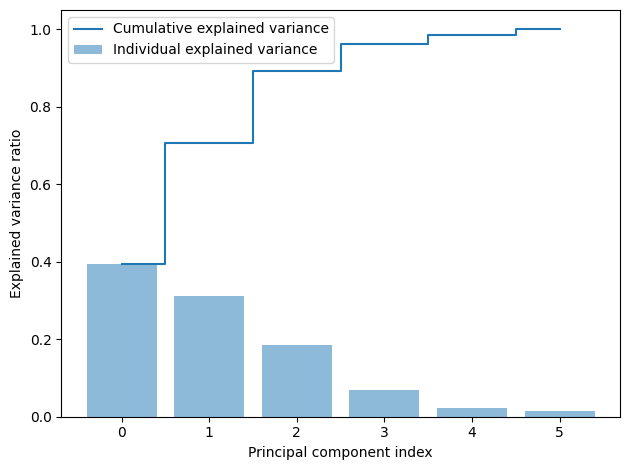

In [91]:
# @title
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(data_k)
X_train_std = sc.transform(data_k)

pca = PCA()

# Determine transformed features
X_train_pca = pca.fit_transform(X_train_std)

# Determine explained variance using explained_variance_ration_ attribute
exp_var_pca = pca.explained_variance_ratio_
#
# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
#
# Create the visualization plot
import matplotlib.pyplot as plt
plt.bar(range(0,len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0,len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [92]:
# Agregue la columna 'Levarage_domain' a pca_dataset
da = chemspace['LeverageMethod_domain']  # Using chemspace DataFrame to access the column
# Restablecer el índice de pca_dataset para que coincida con chemspace
pca_dataset = pca_dataset.reset_index(drop=True)
# Agregar la nueva columna a pca_dataset
pca_dataset['LeverageMethod_domain'] = da

## Representación del espacio químico por PCA



### Preparación

In [93]:
# Crea una columna en pca_dataset que se llamará cn, tendra valores numéricos uno para cada tipo de valor de Cluster_number
# Crear una asignación de valores de Cluster_number a valores numéricos
cluster_mapping = {cluster: i + 1 for i, cluster in enumerate(sorted(pca_dataset['Cluster_number'].unique()))}
# Crea la columna 'cn' en función del mapeo
pca_dataset['cn'] = pca_dataset['Cluster_number'].map(cluster_mapping)
# Crea una columna en pca_datset, se llamará cn_s, tendra valores en cadenas dirán cluster + n, donde es el número de cluster
pca_dataset['cn_s'] = 'cluster ' + pca_dataset['cn'].astype(str)
# Cree la columna 'G2' en función de la asignación
pca_dataset['fraction1'] = pca_dataset['G'].map(g_mapping)

In [94]:
# @title
#Graficar gráfica de dispersión Activity vs PC1

#________________Por si se enciman los datos_________________________________
a = pca_dataset.copy()
# a = pca_dataset[pca_dataset['G'] != 'xplor'].copy()
#a = pca_dataset[pca_dataset['fraction1'].isin([])]# Filter out 'xplor' group
#a = pca_dataset[pca_dataset['cn'].isin([1,2,3,4,5,6,.7,8,9,10,11,12,13])]
#________________Definimos la gráfica_______________________________________

dato1='component1'
dato3='Activity'
#________________
dato2='component2'
#___________________________________________________________________________
fig_pca = px.scatter(data_frame=a, #Por si se enciman los datos
                     #____coordenadas______________--
                     x=dato1,y=dato2,
                     #_____Color_____________-color='cn',
                     color='G',
                     color_discrete_map={'data': 'blue', 'comercial': 'red'}, # Invierte colores
                     #______________________
                     title=f'{dato2} vs {dato1}',
                     width=800,height=600)
#______________formateo_______________________________________________________
fig_pca.update_layout(plot_bgcolor="white", paper_bgcolor="white") # Elige color del fondo
fig_pca.update_traces(marker=dict(line=dict(width=1, color='black'))) # Configuración de marcador agregada
fig_pca.update_traces(marker=dict(size=6)) # Aumentar el tamaño del marcador
#______________________________________________________________________________

# Añadir anotaciones SÓLO para puntos 'comerciales'
for index, row in a.iterrows():
    if row['G'] == 'comercial': # Solo agregue etiquetas para el grupo 'comercial'
        fig_pca.add_annotation(
            x=row[dato1],
            y=row[dato2],
            text=row['Cmpd'],
            showarrow=False,
            yshift=10,  # Desplazar el texto ligeramente por encima del punto
            font=dict(
                size=10,
                color="black"
            )
        )

app_marker2dpca = molplotly.add_molecules(fig=fig_pca,
                                     #_____________dataframe___________________
                                     df=a,
                                     #__________________________________________
                                     smiles_col='SMILES',
#                                    title_col='Cmpd',
                                     #_____________color_________________________
                                     color_col='G',
                                     #color_col='cn',
                                     #_________________________________________
                                    fontsize=20, width=220,
                                     caption_cols=[dato3, 'Cmpd'],
                                     show_coords=False)


/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



In [95]:
# @title
#Grafica de dispersión en 3D Activity vs PC1 vs PC2
#________________Por si se enciman los datos_________________________________

a = pca_dataset.copy()
#a = pca_dataset[pca_dataset['fraction1'].isin([])]
#a = pca_dataset[pca_dataset['cn'].isin([6,9,#10,11,12,13])]

#________________Definimos la gráfica_______________________________________
dato1='component1'
#dato2='Activity'
dato2='component3'
dato3='component2'
#_________
dato4='Activity'
#dato4='component3'
#__________________________________________________________________________
fig_pca = px.scatter_3d(data_frame=a,
                        #data_frame=a, #Por si se enciman los datos
                        #______coordenadas__________________________________
                        x=dato3,
                        y=dato1,
                        z=dato2,
                        #______color________________________________________
                        color='G',
                        #color='cn',
                        #___________________________________________________
                        title=f'{dato2} vs {dato1} vs {dato3}',
                        width=900, height=900)
#______________formateo_______________________________________________________
fig_pca.update_layout(plot_bgcolor="white", paper_bgcolor="white") #Set background color
fig_pca.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig_pca.update_traces(marker=dict(size=5)) # Increase marker size
#______________________________________________________________________________
app_marker3dpca = molplotly.add_molecules(fig=fig_pca,
                                     #___________dataframe__________________
                                     df=a,
                                     #df=a,
                                     #______________________________________
                                     smiles_col='SMILES',
                                   #  title_col='cn_s',
                                     #____________color_____________________
                                     #color_col='cn',
                                     color_col='G',
                                     #________________________________________
                                     show_coords=False,
                                     caption_cols=[dato4,'Cmpd','G'],
                                     fontsize=15, width=210)


/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



### Gráficas

In [96]:
figx.update_layout(width=800, height=250)
figx.show()
app_marker2dpca.run(port=8708)
app_marker3dpca.run(port=8709)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Representación del Espacio Químico por T-SNE

## Preparación



La principal aplicación de la técnica t-SNE es la transformación no lineal de los datos, lo que nos permite visualizar la representación de nuestros datos en un espacio de dos o tres dimensiones, dado que las transformaciones son no lineales, esto evita que se acumulen los puntos en el centro (a diferencia de la técnica de PCA) tratando de preservar la estructura de vecindad.

In [97]:
# @title
## Entrenar modelo t-SNE
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
data_tsne = chemspace.copy()
data_tsne = data_tsne.drop(labels = ["Cmpd", "Cluster_number","SMILES",'Activity','G', 'LeverageMethod_domain',	'G2',	'cn_s',	'cn'],axis = 1)
data_tsne = StandardScaler().fit_transform(data_tsne)
tsne = TSNE(n_components=3, verbose=1, perplexity=3, max_iter=10000, early_exaggeration=5)
tsne_results = tsne.fit_transform(data_tsne)
#tsne_results
# Seleccionar impormación complementaria
label = chemspace[["Cmpd", "Cluster_number","SMILES",'Activity','G', 'LeverageMethod_domain',	'G2',	'cn_s',	'cn']]
label = label.to_numpy()

# Concatenar matrices de numpy
arr = np.concatenate((label, tsne_results), axis = 1)

# Crear un nuevo dataframe
tsne_dataset = pd.DataFrame(data=arr,
                            columns = ["Cmpd", "Cluster_number","SMILES",'Activity','G','LeverageMethod_domain','G2', 'cn_s',	'cn','axis1', 'axis2','axis3'])
#tsne_dataset

# prompt: ordena tsne_dataset por orden ascendente en cn_s

tsne_dataset = tsne_dataset.sort_values(by=['cn_s'])
#tsne_dataset

# prompt: en tsne_dataset elimina los lementos repetidos

# Eliminar filas duplicadas en tsne_dataset basándose en la columna 'SMILES'
tsne_dataset = tsne_dataset.drop_duplicates(subset='SMILES')
#tsne_dataset

[t-SNE] Computing 10 nearest neighbors...
[t-SNE] Indexed 2202 samples in 0.013s...
[t-SNE] Computed neighbors for 2202 samples in 0.018s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2202
[t-SNE] Computed conditional probabilities for sample 2000 / 2202
[t-SNE] Computed conditional probabilities for sample 2202 / 2202
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 2.968038
[t-SNE] KL divergence after 10000 iterations: -8.741791


In [98]:
import plotly.express as px
import molplotly

# Filter out 'xplor' group from tsne_dataset
tsne_dataset_filtered = tsne_dataset.copy()
# tsne_dataset_filtered = tsne_dataset[tsne_dataset['G'] != 'xplor']

fig_tsne2d = px.scatter(tsne_dataset_filtered,
                      x='axis1', y='axis2',
                      #color='cn',
                      color='G',
                        title='t-SNE',
                      #color_discrete_sequece=px.colors.qualitative.Plotly,
                      width=900,height=700)

# Set background color to white
fig_tsne2d.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_tsne2d.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig_tsne2d.update_traces(marker=dict(size=12)) # Increase marker size
# También puedes usar una sintaxis más directa (atajo):
fig_tsne2d.update_layout(hoverlabel_font_size=20)

#fig_tsne.update_layout(showlegend=False) # Esta línea elimina la leyenda.
#fig_tsne.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="center", x=-10.0))
app_marker2d = molplotly.add_molecules(fig=fig_tsne2d,
                                       df=tsne_dataset_filtered,
                                       smiles_col='SMILES',
                                       #title_col='Cmpd',
                                       #color_col='cn',
                                       color_col='G',
                                       width=350, fontsize= 25,
                                       caption_cols=['cn_s','Activity', 'LeverageMethod_domain'],
                                          show_coords=False
                                       )
#_________________________________________________________________________________________________________


fig_tsne3d = px.scatter_3d(tsne_dataset_filtered,
                      x='axis1', y='axis3', z='axis2',
                      color='G', #Otra opción de color
                      #color='cn', #Otra opción de color
                      title='t-SNE',
                      hover_data={'cn_s':True,'Activity':True, 'axis1': False, 'axis2': False, 'axis3':False},
                      hover_name='Cmpd',
                      width=900,height=700)

# Establecer el color de fondo en blanco
fig_tsne3d.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_tsne3d.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig_tsne3d.update_traces(marker=dict(size=8)) # Increase marker size
# También puedes usar una sintaxis más directa (atajo):
fig_tsne3d.update_layout(hoverlabel_font_size=20)

app_marker3d = molplotly.add_molecules(fig=fig_tsne3d,
                                       df=tsne_dataset_filtered,
                                       smiles_col='SMILES',
                                       color_col='G',
                                       width=350, fontsize= 25,
                                       caption_cols=['Cmpd', 'cn_s','Activity', 'LeverageMethod_domain'],
                                       show_coords=False
                                      )

#fig_tsne.update_layout(showlegend=False) # Esta línea elimina la leyenda.
#fig_tsne.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="center", x=-10.0))
#                                       )
#_____________________________________________________________________________________________________


/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.

/usr/local/lib/python3.13/dist-packages/jupyter_dash/jupyter_app.py:103: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



## Gráficas tSNE

In [99]:
app_marker2d.run(port=8710)
app_marker3d.run(port=8711)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# UMAP



In [100]:
# Select the descriptor columns from chemspace for UMAP
descriptor_cols = ['HBA', 'HBD', 'RB', 'LogP', 'TPSA', 'MW']
X_descriptors = chemspace[descriptor_cols].copy()

# Handle potential NaN values by imputing with the mean (similar to previous steps for other models)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_descriptors)

# Apply StandardScaler to the descriptors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply UMAP dimensionality reduction (using 3 components for more detail, can be changed to 2)
reducer = umap.UMAP(n_components=3, random_state=RANDOM_STATE) #funcion importante
umap_results = reducer.fit_transform(X_scaled)

# Create a DataFrame for UMAP results
umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2', 'UMAP3'])

# Add relevant original columns to the UMAP DataFrame
umap_df['Cmpd'] = chemspace['Cmpd'].values
umap_df['SMILES'] = chemspace['SMILES'].values
umap_df['Activity'] = chemspace['Activity'].values
umap_df['Cluster_number'] = chemspace['Cluster_number'].values
umap_df['G'] = chemspace['G'].values



/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [101]:
import plotly.express as px
import warnings

warnings.filterwarnings("ignore", message="JupyterDash is deprecated, use Dash instead.")

# Prepare data for plotting, ensuring 'G' is properly handled for color
umap_df['G_category'] = umap_df['G'].astype('category')

# 2D UMAP Scatter Plot
fig_umap2d = px.scatter(umap_df,
                        x='UMAP1', y='UMAP2',
                        color='G_category',
                        color_discrete_map={'data': 'blue', 'xplor': 'red', 'comercial': 'green'},
                        title='2D UMAP Visualization of Chemical Space',
                        width=900, height=700)

fig_umap2d.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_umap2d.update_traces(marker=dict(line=dict(width=1, color='black')))
fig_umap2d.update_traces(marker=dict(size=12))
fig_umap2d.update_layout(hoverlabel_font_size=20)

app_umap2d = molplotly.add_molecules(
    fig=fig_umap2d,
    df=umap_df,
    smiles_col='SMILES',
    color_col='G_category',
    caption_cols=['Cmpd', 'Activity', 'Cluster_number', 'G'],
    fontsize=15, width=220
)

print('2D UMAP plot created. Running on port 8717.')
app_umap2d.run(port=8717)

# 3D UMAP Scatter Plot
fig_umap3d = px.scatter_3d(umap_df,
                         x='UMAP1', y='UMAP2', z='UMAP3',
                         color='G_category',
                         color_discrete_map={'data': 'blue', 'xplor': 'red', 'comercial': 'green'},
                         title='3D UMAP Visualization of Chemical Space',
                         width=900, height=900)

fig_umap3d.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig_umap3d.update_traces(marker=dict(line=dict(width=1, color='black')))
fig_umap3d.update_traces(marker=dict(size=8))
fig_umap3d.update_layout(hoverlabel_font_size=20)

app_umap3d = molplotly.add_molecules(
    fig=fig_umap3d,
    df=umap_df,
    smiles_col='SMILES',
    color_col='G_category',
    caption_cols=['Cmpd', 'Activity', 'Cluster_number', 'G'],
    fontsize=15, width=210
)

print('3D UMAP plot created. Running on port 8718.')
app_umap3d.run(port=8718)

2D UMAP plot created. Running on port 8717.


<IPython.core.display.Javascript object>

3D UMAP plot created. Running on port 8718.


<IPython.core.display.Javascript object>

# REPRESENTACIÓN DEL SOPORTE VECTORIAL

## Preparación de Dataframes

In [102]:
df_info = df_info.assign(fraction=fractions)

In [103]:
# Crear nombres de columnas
column_names = [f'PC{i}' for i in range(1, n_pca + 1)]

In [104]:
# Añadimos tres columna que nos permitirá visualizar la información de los clusters con plotly
df_info['fraction1'] = df_info['fraction'].astype('category').cat.codes
df_info['cn'] = df_info['Cluster_number'].astype('category').cat.codes
df_info['cn_s'] = 'Cluster ' + df_info['Cluster_number'].astype(str)
print(df_info.shape)
#df_info.head()

(425, 7)


### test

In [105]:
# Aplicar la canalización hasta el paso especificado
df_pca_test_data = pipeline[:-1].transform(x_test)

In [106]:
# Crea el DataFrame usando los datos transformados
df_pca_test= pd.DataFrame(data=df_pca_test_data[:,:n_pca], columns=column_names)
df_info_train = df_info[df_info['fraction'] == 'train']
df_info_test = df_info[df_info['fraction'] == 'test']
df_pca_test = df_pca_test.assign(Activity = y_test)
df_info_test = df_info_test.reset_index(drop=True)
df_pca_test = df_pca_test.reset_index(drop=True)
df_pca_test = pd.concat([df_pca_test, df_info_test], axis=1)
#df_pca_test

### val

In [107]:
# Apply the pipeline up to the specified step
df_pca_val_data = pipeline[:-1].transform(df_val)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning:

X has feature names, but VarianceThreshold was fitted without feature names



In [108]:
# Create the DataFrame using the transformed data
df_pca_val = pd.DataFrame(data=df_pca_val_data[:,:n_pca], columns=column_names)
df_pca_val = df_pca_val.assign(Activity = xplor_pred['pred'])
df_pca_val = pd.concat([df_pca_val, xplor], axis =1)
df_pca_val['Cluster_number'] = 13
df_pca_val['fraction'] = 'xplor'
df_pca_val = df_pca_val.assign(da =xplor_pred['LeverageMethod_domain'])
#df_pca_val

filtered = df_pca_val[(df_pca_val['da'] > da_limit) & (df_pca_val['Activity'] >Activity_limit)]
filtered = filtered.drop('da', axis =1)
filtered = filtered.reset_index(drop=True)
# filtrado
# Añadimos tres columna que nos permitirá visualizar la información de los clusters con plotly
filtered['fraction1'] = 2
filtered['cn'] = len(set(cluster_id)) + 1
filtered['cn_s'] = 'Cluster ' + filtered['Cluster_number'].astype(str)

### train

In [109]:
# Aplicar el pipleline hasta el paso especificado
df_pca_train_data = pipeline[:-1].transform(x_train)

In [110]:
# Crea el DataFrame usando los datos transformados
df_pca_train = pd.DataFrame(data=df_pca_train_data[:,:n_pca], columns=column_names)

#df_pca_train.shape
df_pca_train = df_pca_train.assign(Activity = y_train)
#df_pca_train
df_info_train = df_info_train.reset_index(drop=True)
df_pca_train = df_pca_train.reset_index(drop=True)
df_pca_train = pd.concat([df_pca_train, df_info_train], axis=1,)
#df_pca_train

###concatenated_df

In [111]:
# Concatenar la, df_pca_test, and df_pca_val
concatenated_df = pd.concat([df_pca_train, df_pca_test, filtered], axis=0, #ignore_index=True
                            )
# prompt: ordena concatenated_df  con cn_s de manera ascendenete
concatenated_df = concatenated_df.sort_values(by=['cn_s'], ascending=True)

## Análisis de PCA

In [112]:
# @title
# prompt: # prompt: haz una gráfica que expli que la varianza acumulda y varianza individual de cada PC, con plot ly, con un ofndo blanco, pon marcas en el eje de las absisas a la altura de 0.8, 0.9, 0.95, 0.99

import plotly.graph_objects as go

# Calcula la varianza explicada acumulada

cumulative_variance = np.cumsum(FEAT_SELECTOR2.explained_variance_ratio_)
# Crea la figura
fig = go.Figure()

# Agrega la traza de varianza individual
fig.add_trace(go.Bar(
    x=[f'PC{i+1}' for i in range(FEAT_SELECTOR2.n_components_)],
    y=FEAT_SELECTOR2.explained_variance_ratio_,
    name='Varianza Individual'
))

# Agrega la traza de varianza acumulada
fig.add_trace(go.Scatter(
    x=[f'PC{i+1}' for i in range(FEAT_SELECTOR2.n_components_)],
    y=cumulative_variance,
    mode='lines+markers',
    name='Varianza Acumulada',
    line=dict(color='green')
))

# Configura el diseño
fig.update_layout(
    title='Varianza Explicada por Componentes Principales para Regresión',
    xaxis_title='Componente Principal',
    yaxis_title='Varianza Explicada',
    plot_bgcolor='white',
    xaxis=dict(
        showgrid=True,
        tickmode='linear',
        dtick=1
    ),
    yaxis=dict(
        showgrid=True
    ),
    shapes=[
        dict(
            type='line',
            yref='y', y0=0.8, y1=0.8,
            xref='paper', x0=0, x1=1,
            line=dict(color='gray', dash='dash')
        ),
        dict(
            type='line',
            yref='y', y0=0.9, y1=0.9,
            xref='paper', x0=0, x1=1,
            line=dict(color='gray', dash='dash')
        ),
        dict(
            type='line',
            yref='y', y0=0.95, y1=0.95,
            xref='paper', x0=0, x1=1,
            line=dict(color='gray', dash='dash')
        ),
        dict(
            type='line',
            yref='y', y0=0.99, y1=0.99,
            xref='paper', x0=0, x1=1,
            line=dict(color='gray', dash='dash')
        )
    ]
)

# Muestra la gráfica
fig.show()


In [113]:
df_pca_train_ = df_pca_train.select_dtypes('number').copy()

In [114]:
# @title
# prompt: # prompt: coloca juntas en una misma celda las dos ultimas gráficas de linea continua, uqe se comparen con el eje de las absisas, correlación en color verde y correlación en color azul

# Calcula las covarianzas con respecto a 'Activity'
#covarianzas_Activity = cov_matrix['Activity'].drop('Activity')

# Calcula los coeficientes de correlación
covarianzas_Activity = df_pca_train_.cov()['Activity'].drop('Activity')

# Crea un DataFrame para la gráfica de covarianzas
df_covarianzas = pd.DataFrame({
    'Componente Principal': covarianzas_Activity.index,
    'Covarianza': covarianzas_Activity.values
})

# Calcula los coeficientes de correlación
correlations = df_pca_train_.corr()['Activity'].drop('Activity')

# Crea un DataFrame para la gráfica de correlaciones
df_correlations = pd.DataFrame({
    'Componente Principal': correlations.index,
    'Correlación': correlations.values
})



df_covarianzas = df_covarianzas.iloc[:-3]
df_correlations = df_correlations.iloc[:-3]


# Crea la figura de Plotly con ambas gráficas
fig = go.Figure()

# Agrega la línea de covarianzas
fig.add_trace(go.Scatter(
    x=df_covarianzas['Componente Principal'],
    y=df_covarianzas['Covarianza'],
    mode='lines+markers',
    name='Covarianza',
    line=dict(color='green')
))

# Agrega la línea de correlaciones
fig.add_trace(go.Scatter(
    x=df_correlations['Componente Principal'],
    y=df_correlations['Correlación'],
    mode='lines+markers',
    name='Correlación',
    line=dict(color='blue')
))

# Agrega una línea de referencia en el eje 0
fig.add_shape(
    type='line',
    x0=df_covarianzas['Componente Principal'].iloc[0],
    x1=df_covarianzas['Componente Principal'].iloc[-1],
    y0=0,
    y1=0,
    line=dict(color='black', dash='dash')
)

# Configura el título y etiquetas de los ejes
fig.update_layout(
    title='Covarianzas y Correlaciones de los Componentes Principales para egresión con respecto a la Actividad',
    xaxis_title='Componente Principal',
    yaxis_title='Valor',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(x=0.8, y=0.1)
)

# Muestra la gráfica
fig.show()


In [115]:
# @title
# creamos pipeline: el modelo final final
steps3 = [
    ("var0", VarianceThreshold(MIN_VARIANCE)),
    ("scaling", SCALER),
    ("feat_selector1", FEAT_SELECTOR1),
    #("feat_selector2", FEAT_SELECTOR2),
    #("regressor", REGRESSOR)
]
pipeline3 = Pipeline(steps3, verbose=True)
pipeline3 = pipeline3.fit(x_train, y_train)
pipeline3.set_params(verbose=False)
#pipeline

[Pipeline] .............. (step 1 of 3) Processing var0, total=   0.0s
[Pipeline] ........... (step 2 of 3) Processing scaling, total=   0.0s
[Pipeline] .... (step 3 of 3) Processing feat_selector1, total= 1.6min


Pipeline(steps=[('var0', VarianceThreshold(threshold=0)),
                ('scaling', StandardScaler()),
                ('feat_selector1',
                 SelectFromModel(estimator=XGBRegressor(base_score=None,
                                                        booster=None,
                                                        callbacks=None,
                                                        colsample_bylevel=None,
                                                        colsample_bynode=None,
                                                        colsample_bytree=0.8,
                                                        device=None,
                                                        early_stopping_rounds=None,
                                                        enable_categorical=True,
                                                        eval_metric=None,
                                                        feature_types=None...
                                                        gamma=None,
                                                        grow_policy=None,
                                                        importance_type=None,
                                                        interaction_constraints=None,
                                                        learning_rate=0.2,
                                                        max_bin=None,
                                                        max_cat_threshold=None,
                                                        max_cat_to_onehot=None,
                                                        max_delta_step=None,
                                                        max_depth=8,
                                                        max_leaves=None,
                                                        min_child_weight=9,
                                                        missing=nan,
                                                        monotone_constraints=None,
                                                        multi_strategy=None,
                                                        n_estimators=1000,
                                                        n_jobs=None,
                                                        num_parallel_tree=None, ...),
                                 max_features=15))])

In [116]:
# @title
# prompt: haz un data frame con las caracteristicas seleccionadas por el pipeline, las columnas serán nombradas con el nombre de las carcteristicas seleccionadas


selected_feature_indices = pipeline3.named_steps['feat_selector1'].get_support(indices=True)
selected_feature_names = df_x.columns[selected_feature_indices]


# Transforme los datos de entrenamiento mediante la canalización hasta el selector de características
transformed_data = pipeline3.transform(x_train)


# Crear un DataFrame con las características y nombres de columnas seleccionados
df_selected_features = pd.DataFrame(transformed_data, columns=selected_feature_names)

#df_selected_features


In [117]:
# @title
#Las cargas (loadings) representan los pesos o coeficientes de los PC's
loadings = []
#Inicia un bucle que itera sobre cada componente principal.
# pca.n_components se refiere al número de componentes principales calculados durante el análisis PCA.
# # pca.components_ es un atributo del objeto PCA ajustado (fit) que almacena las cargas (loadings) de todos los componentes principales.
for i in range(FEAT_SELECTOR2.n_components):
  loadings.append(FEAT_SELECTOR2.components_[i])
#pca loadings es una dataframe que relaciona los descriptores con los pesos de los PCA´s
pca_loadings = pd.DataFrame(data=loadings, columns=df_selected_features.columns)
# Renombramos las columnas
#pca_loadings = pca_loadings.rename(columns={0: "HBA", 1: "HBD", 2: "RB", 3: "LogP", 4: "TPSA", 5: "MW"})
# A pca_loadings vuelve cambia el indice qu ecomience desde uno
pca_loadings.index = range(1, len(pca_loadings) + 1)

In [118]:
# @title
# Obtenemos las ecuaciones de PC's
equations = {}
for index, row in pca_loadings.iterrows():
  equation = "PC{} = ".format(index)
  for col, value in row.items():
    equation += "{:.4f}*{} + ".format(value, col)
  equations["PC{}".format(index)] = equation[:-3]  # Remove the last " + "
for pc, equation in equations.items():
  print(equation)

PC1 = -0.0002*SpDiam_A + 0.4333*ATS3p + 0.4382*ATS4p + -0.1355*AATS7m + -0.1749*AATS7pe + 0.0418*ATSC2dv + 0.0472*GATS1are + -0.0187*NsssP + 0.2159*SssCH2 + 0.1411*SaasN + 0.3606*SssssN + 0.0402*AETA_beta + 0.4518*VSA_EState3 + 0.2465*n6Ring + 0.3222*nHRing
PC2 = 0.3797*SpDiam_A + -0.1093*ATS3p + -0.1290*ATS4p + 0.3610*AATS7m + 0.4183*AATS7pe + -0.1095*ATSC2dv + -0.2452*GATS1are + 0.2305*NsssP + 0.3411*SssCH2 + 0.2769*SaasN + 0.1340*SssssN + 0.1581*AETA_beta + -0.1104*VSA_EState3 + 0.3661*n6Ring + 0.1203*nHRing
PC3 = -0.0556*SpDiam_A + -0.1037*ATS3p + -0.0842*ATS4p + -0.0046*AATS7m + -0.1156*AATS7pe + 0.5376*ATSC2dv + 0.4128*GATS1are + 0.4841*NsssP + -0.0652*SssCH2 + 0.2155*SaasN + 0.0397*SssssN + 0.4406*AETA_beta + 0.0494*VSA_EState3 + 0.0234*n6Ring + -0.1501*nHRing
PC4 = 0.4713*SpDiam_A + 0.2197*ATS3p + 0.1834*ATS4p + 0.1717*AATS7m + -0.2616*AATS7pe + 0.0128*ATSC2dv + -0.0439*GATS1are + 0.1742*NsssP + -0.1772*SssCH2 + -0.4163*SaasN + -0.1396*SssssN + -0.0741*AETA_beta + 0.0338*VSA_ES

In [119]:
# Crea una figura
figy = go.Figure()
# Itera sobre cada índice (PC) y agrega trazas (inforación de cada PC) al gráfico de barras
for index in pca_loadings.index:
  figy.add_trace(go.Bar(x=pca_loadings.columns, # Nombres de los descriptores
                        y=pca_loadings.loc[index],  # Valores para cada uno de los PC's
                        name=index))  # Nombre de la traza (PC)
#____________Formateo_______________
figy.update_layout(title="Contribución de los Descriptores a cada PC para regresión",
                   xaxis_title="Descriptores",
                   yaxis_title="Weight",
                   plot_bgcolor='white',
                   paper_bgcolor='white',
                   barmode='group')  # Agrupa las barras por descriptor
figy.show()# Muestra la figura

In [120]:
import plotly.express as px
import molplotly
import pandas as pd # Ensure pandas is imported

# --- Prepare data for plotting within this cell ---

# 1. Prepare data for original compounds (including all Mordreds)
chemspace_plot_data = df_x.copy() # All Mordred descriptors from original data
chemspace_plot_data['Activity'] = df_y['Activity'].values # Add Activity
chemspace_plot_data = pd.merge(chemspace_plot_data, df_info[['Cmpd', 'SMILES', 'Cluster_number']], left_index=True, right_index=True, how='left')

# Prepare 'LeverageMethod_domain' from results_da by renaming the 'Score' column
results_da_for_merge = results_da.copy()
results_da_for_merge = results_da_for_merge.rename(columns={'Score': 'LeverageMethod_domain'}) # Rename 'Score' to 'LeverageMethod_domain'
chemspace_plot_data = pd.merge(chemspace_plot_data, results_da_for_merge[['LeverageMethod_domain']], left_index=True, right_index=True, how='left')
chemspace_plot_data['G'] = 'data'

# 2. Prepare data for exploration/commercial compounds (including all Mordreds)
chemspace_plot_xplor = xplor_mordred.copy() # All Mordred descriptors and base info
chemspace_plot_xplor['Activity'] = xplor_pred['pred'].values # Predicted Activity
chemspace_plot_xplor['LeverageMethod_domain'] = xplor_pred['LeverageMethod_domain'].values # LeverageMethod_domain
# Ensure 'G' and 'Cluster_number' are properly set from the xplor DataFrame used to create xplor_mordred.
# xplor_mordred already contains 'G' and 'Cluster_number' from `xplor`.

# Drop any components/ZINC_ID columns if they were previously added, to keep it clean.
chemspace_plot_xplor = chemspace_plot_xplor.drop(columns=['ZINC_ID', 'component1', 'component2', 'component3'], errors='ignore')

# 3. Concatenate them into a single DataFrame for plotting
a = pd.concat([chemspace_plot_data, chemspace_plot_xplor], ignore_index=True)

# --- End of data preparation ---

# Create the scatter plot using plotly.express
fig = px.scatter(a, x="MATS7p", y="Activity", # Changed x-axis to ATSC8c
                 title="Dispersión de MATS7p vs Actividad", # Updated title
                 color='G', # Color by 'G' (data, xplor, comercial)
                 symbol='G', # Use different symbols for different groups
                 hover_name="Cmpd", # Show compound name on hover
                 width=900, height=600)

# Customize the plot layout
fig.update_layout(
    plot_bgcolor="white",  # Set plot background color to white
    paper_bgcolor="white"    # Set paper background color to white
)

# Customize marker appearance
fig.update_traces(
    marker=dict(line=dict(width=1, color='black')), # Black border for markers
    marker_size=12 # Increase marker size
)

# Update hover label font size
fig.update_layout(hoverlabel_font_size=16)

# Add molplotly for molecule visualization on hover
app_mol_mw_atsc0s = molplotly.add_molecules(
    fig=fig,
    df=a,
    smiles_col='SMILES',
    color_col='G',
    caption_cols=['Cmpd', 'Activity', 'G'],
    fontsize=15, width=220
)

# Run the molplotly app
app_mol_mw_atsc0s.run(port=8719)

<IPython.core.display.Javascript object>

## SVR representación



Se muestra el plano de regresión para el primer componente principal (PC1), donde se observan los compuestos propuestos (cuadrados verdes), los compuestos del grupo de entrenamiento (círculos azules) y las moléculas del grupo de prueba (rombos rojos) con relación a la predicción de la actividad biológica (pIC50) del SVR.

### Vectores de Soporte

In [121]:
# @title
dataframe=df_pca_train_
y= dataframe['Activity']

pipeline.fit(x_train, y_train) # Ajustar la tubería a los datos de entrenamiento
df_pcasvr = pipeline[:-1].transform(x_train) # Aplicar transformaciones (excepto el regresor) a los datos de entrenamiento
# Crear el DataFrame con los datos transformados
df_pcasvr = pd.DataFrame(data=df_pcasvr[:,:n_pca], columns=column_names)

XD = df_pcasvr.copy()
# Crear un rango de valores PC1 para predicción
x_range = np.linspace(XD[XD.columns].min(), XD[XD.columns].max(), 100)
# Predecir valores de actividad usando el DataFrame
REGRESSOR.fit(XD, y)
y_pred = REGRESSOR.predict(XD)
#y_pred = REGRESSOR.predict(x_range)
# Calculate margins (epsilon)
epsilon = float(REGRESSOR.epsilon)

#_______________________________________________________________________________
# --- Agregar vectores de soporte---
support_vectors = dataframe.iloc[REGRESSOR.support_, :]
#support_vector_predictions = REGRESSOR.predict(support_vectors[[pca_name]])
support_vector_predictions = REGRESSOR.predict(support_vectors[XD.columns])  # Utilice todas las columnas de X para la predicción


on_margin = np.abs(support_vectors['Activity'] - support_vector_predictions) >= (epsilon - 1e-6)
not_on_margin = ~on_margin

# Count purple (not on margin) and green (on margin) support vectors
purple_support_vectors = sum(not_on_margin)
green_support_vectors = sum(on_margin)

print(f'Total de Vectores de Soporte (VS): {len(df_pca_train)}, 100%')
print(f"VS activos: {purple_support_vectors}, {round(purple_support_vectors/len(df_pca_train)*100)}%")
print(f"VS con error: {green_support_vectors}, {round(green_support_vectors/len(df_pca_train)*100)}%")
print(f'Molécula dentro de márgenes: {len(df_pca_train_)-purple_support_vectors-green_support_vectors}, {round((len(df_pca_train)-purple_support_vectors-green_support_vectors)/len(df_pca_train_)*100)}%')

Total de Vectores de Soporte (VS): 297, 100%
VS activos: 36, 12%
VS con error: 215, 72%
Molécula dentro de márgenes: 46, 15%


/tmp/ipykernel_3943/3359456633.py:7: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_3943/3359456633.py:10: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



<IPython.core.display.Javascript object>

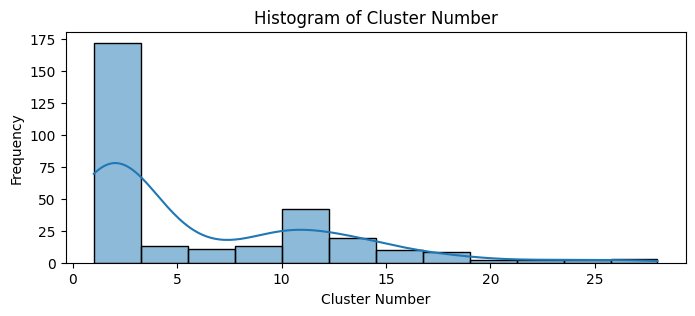

In [122]:
# @title
df_pca_traink = df_pca_train.assign(on_margin=on_margin, not_on_margin=not_on_margin)
# Agregue una nueva columna 'VS' a df_pca_train según las condiciones
df_pca_traink['VS'] = 'Dentro de los márgenes'  # Default value for all rows

# Establezca 'VS' en 0 donde 'on_margin' es Verdadero
df_pca_traink.loc[df_pca_traink['on_margin'].fillna(False), 'VS'] = 'VS con error'  # Handle NaN values

# Establezca 'VS' en 1 donde 'not_on_margin' es Verdadero
df_pca_traink.loc[df_pca_traink['not_on_margin'].fillna(False), 'VS'] = 'VS activos'

fig = px.scatter(df_pca_traink, x="Cluster_number", y="Activity", color="VS",
                 title="Activity vs. Cluster Number",
                 width=800, height=550)

fig.update_layout(plot_bgcolor="white",  # Establecer color de fondo
                  paper_bgcolor="white")   # Establecer color de fondo del papel
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) # Configuración de marcador agregada
fig.update_traces(marker=dict(size=12)) # Aumentar el tamaño del marcador
#fig.update_layout(hoverlabel_font_size=20)
app_marker = molplotly.add_molecules(fig=fig,
                                     df=df_pca_traink,
                                     smiles_col='SMILES', #title_col='Cmpd',
                                     color_col='VS',
                                     fontsize=15, width=220)
# Assuming df_d is already created as in your provided code
plt.figure(figsize=(8, 3))  # Adjust figure size as needed
sns.histplot(df_pca_train['Cluster_number'], kde=True, bins=12)  # kde=True agrega una estimación de densidad del kernel
plt.title('Histogram of Cluster Number')
plt.xlabel('Cluster Number')
plt.ylabel('Frequency')

#fig.show()
app_marker.run(port=8712)

In [123]:
# @title
x_eje = 'PC1'
fig = px.scatter(df_pca_traink, x=x_eje, y="Activity", color="VS",
                 title=f"Activity vs. {x_eje}",
                 width=800, height=550)

fig.update_layout(plot_bgcolor="white",  # Set plot background color
                  paper_bgcolor="white")   # Set paper background color
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig.update_traces(marker=dict(size=12)) # Increase marker size
#fig.update_layout(hoverlabel_font_size=20)
app_marker = molplotly.add_molecules(fig=fig,
                                     df=df_pca_traink,
                                     smiles_col='SMILES',# title_col='Cmpd',
                                     color_col='VS',
                                     fontsize=15, width=220)

app_marker.run(port=8713)

<IPython.core.display.Javascript object>

In [124]:
# @title
from IPython.utils import io
import tqdm.notebook
import os, os.path, sys, random, subprocess
total = 100
hj= False
if hj== True:
  with tqdm.notebook.tqdm(total=total) as pbar:
    with io.capture_output() as captured:
      pbar.update(0)
      # VEAMOS CUÁLES MOLÉCULAS DEl GRUPO DE EXPLORACIÓN ENTRAN A LOS MARGENES, SOBRE LOS MÁRGENES O FUERA DE LOS MÁRGENES

      # --- Agregar vectores de soporte ---
      support_vector_predictions = support_vector_predictions[filtered.index] # or filtered.index.values
      #Proceed with calculations
      gg = np.array(filtered['Activity'])
      dif = gg - support_vector_predictions

#_____________________________________________________________
      filteredk = filtered.assign(dif=dif, #not_on_margin=not_on_margin
                            )
      fig = px.scatter(filteredk, x="PC1", y="dif", color="Activity",
                 title="Xplor que son SV, o dentro del margen",
                 size='Activity',
                 width=700, height=500)

      fig.update_layout(plot_bgcolor="white",  # Establecer color de fondo
                  paper_bgcolor="white")   # Establecer color de fondo del papel
      fig.update_traces(marker=dict(line=dict(width=1, color='black'))) # Configuración de marcador agregada
      fig.update_traces(marker=dict(size=12)) # Aumentar el tamaño del marcador
      fig.update_layout(hoverlabel_font_size=20)
      fig.add_hline(y=0, line_width=3, line_color="green")
      fig.add_hline(y=epsilon, line_width=1, line_dash="dash", line_color="green")
      fig.add_hline(y=-epsilon, line_width=1, line_dash="dash", line_color="green")
      fig.add_hline(y=0.5, line_width=1, line_dash="dash", line_color="green")


      app_marker = molplotly.add_molecules(fig=fig,
                                     df=filteredk,
                                     smiles_col='SMILES',# title_col='Cmpd',
                                     color_col='Activity',
                                     caption_cols=['Activity', 'dif'],
                                     show_coords=False,
                                     fontsize=15, width=220)


       #fig.show()
      app_marker.run(port=8714)



### Preparación

In [125]:
# @title

pca_name = 'PC1'

dataframe=df_pca_train_
#dataframe=concatenated_df
# Entrenar un modelo SVR
X = dataframe[[pca_name]] #combined_df[['PC1']]  # Using only PC1 for 2D visualization
y= dataframe['Activity']
#y = pIC50 #combined_df['Activity']
REGRESSOR.fit(X, y)
#______________________________________________________________________________________________________
# Crear un rango de valores PC1 para predicción
x_range = np.linspace(X[pca_name].min(), X[pca_name].max(), 100).reshape(-1, 1)

# Predecir valores de actividad
y_pred = REGRESSOR.predict(x_range)

# Calcular márgenes (épsilon)
epsilon = float(REGRESSOR.epsilon)
#
#______________________________________________________________________________________________________

#________________Por si se enciman los datos_________________________________
a= concatenated_df
#a = concatenated_df[concatenated_df['fraction1'].isin([1])]
#a = df_pca_svr_1[df_pca_svr_1['Cluster_number'].isin([7])] # que clusters seleccionamos

#________________Definimos la gráfica__________________________________________________________________

# Crea el gráfico de dispersión con la línea de regresión SVR
figa = px.scatter(a, x=pca_name, y='Activity',
                  title=f'{pca_name} Representación de la regresión por SVR en función del PC1',
                  #opacity=0.7,
                  color= 'fraction',
                  symbol='fraction',
                  hover_data =['cn_s'],
                  hover_name = 'Cmpd',
                  width=1200,height=700) # increased maximum size

#_____________________________________________________________________________________________________

# Agregue la línea de regresión SVR (en azul)
figa.add_trace(go.Scatter(x=x_range.flatten(), y=y_pred, mode='lines', name='SVR kernel', line=dict(color='blue')))

# Añadir márgenes superior e inferior
figa.add_trace(go.Scatter(x=x_range.flatten(), y=y_pred + epsilon, mode='lines',
                         line=dict(color='gray', dash='dash'), name='Upper Margin'))
figa.add_trace(go.Scatter(x=x_range.flatten(), y=y_pred - epsilon, mode='lines',
                         line=dict(color='gray', dash='dash'), name='Lower Margin'))
#_______________________________________________________________________________
# --- Agregar vectores de soporte ---
support_vectors = dataframe.iloc[REGRESSOR.support_, :]
support_vector_predictions = REGRESSOR.predict(support_vectors[[pca_name]])

# Identificar vectores de soporte en los márgenes
on_margin = np.abs(support_vectors['Activity'] - support_vector_predictions) >= (epsilon - 1e-6
                                                                                 )  # Usando una pequeña tolerancia
# Trazar vectores de soporte en los márgenes en color rosa
#figa.add_trace(go.Scatter(x=support_vectors.loc[on_margin, pca_name],
                        #y=support_vectors.loc[on_margin, 'Activity'],
                         #mode='markers',
                         #marker=dict(size=26,
                                     #color='green'
                                     #),
                         #name='VS con error'))

# Grafique otros vectores de soporte en naranja
#figa.add_trace(go.Scatter(x=support_vectors.loc[~on_margin, pca_name],
                         #y=support_vectors.loc[~on_margin, 'Activity'],
                         #mode='markers',
                         #marker=dict(size=26,
                                     #color='purple',
                                     #symbol='+'
                                     #),
                         #name='VS activos'))

# Resaltar vectores de soporte

#figa.add_trace(go.Scatter(x=support_vectors[pca_name],
#                         y=support_vectors['Activity'],
#                         mode='markers',
#                         marker=dict(size=10, color='red'),  # Resaltar vectores de soporte
#                         name='Support Vectors'))
#_______________________________________________________________________________

# Establecer el color de fondo en blanco
figa.update_layout(plot_bgcolor='white', paper_bgcolor='white')
#figa.update_layout(legend=dict(font=dict(size=10)))  # Aumentar el tamaño de fuente de la leyenda
#fig.update_layout(font=dict(size=8)) # Aumentar el tamaño de fuente para todos los elementos de texto
figa.update_layout(hoverlabel_font_size=20)
#figa.update_layout(showlegend=False) # Esta línea elimina la leyenda.
#figa.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="right", x=0))
figa.update_traces(marker=dict(line=dict(width=1, color='black'))) # Configuración de marcador agregada
figa.update_traces(marker=dict(size=12)) # Aumentar el tamaño del marcador


if figa is not None:
  print('figa, se creó')

figa, se creó


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SVR was fitted with feature names



In [126]:
# @title
# Crea el gráfico de dispersión con la línea de regresión SVR
#________________Por si se enciman los datos_________________________________
a = concatenated_df[concatenated_df['fraction1'].isin([0,1,2])]
#a = df_pca_svr_1[df_pca_svr_1['Cluster_number'].isin([7])] # que clusters seleccionamos
#________________Definimos la gráfica______________________________
fig = px.scatter(a, x=pca_name, y='Activity',
                 title=f'{pca_name} Representación de la regresión por SVR en función del PC1',
                 #opacity=0.7,
                 #size = 'Activity', # tamaño añadido en función de la actividad
                 #size_max=10,
                 symbol ='fraction',
                 color='fraction',
                 width=1200,height=700,
                 labels=dict(font=dict(size=20))
                 ) # increased maximum size
#______________________________________________________________________________
#_______________________________________________________________________________
# Establecer el color de fondo en blanco
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.update_traces(marker=dict(line=dict(width=1, color='black'))) # Configuración de marcador agregada
fig.update_traces(marker=dict(size=12)) # Aumentar el tamaño del marcador
#fig.update_layout(legend=dict(font=dict(size=10)))  # Aumentar el tamaño de fuente de la leyenda
#fig.update_layout(showlegend=False) # Esta línea elimina la leyenda.
#fig.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-20.0, xanchor="right", x=0.0))
#_______________________________________________________________________________
app = molplotly.add_molecules(fig=fig,
                              #__________dataframe_____________________
                              #df=p,
                              df=a,
                              #________________________________________
                              smiles_col='SMILES',
                             # title_col='Cmpd',
                              #__________color_________________________
                              color_col='fraction',
                              #color_col='cn',
                              #________________________________________
                              #symbol_col='fraction',
                              caption_cols=['Cmpd', 'Activity','cn_s','fraction'],
                              show_coords=False,
                              fontsize=20, width=220)
#app.run(port=8060)
#figx.update_layout(width=1050,height=250)
#figx.show()

if app is not None:
  print('app, se creó')

app, se creó


### Gráficas

In [127]:
figy.update_layout(width=900,height=280)
figy.show()
figa.show()
app.run(port=8715)

<IPython.core.display.Javascript object>

In [128]:
# prompt: cuantos vectores de soporte morados y verdes hay

# Encuentre vectores de soporte en los márgenes y no en los márgenes

on_margin = np.abs(support_vectors['Activity'] - support_vector_predictions) >= (epsilon - 1e-6)
not_on_margin = ~on_margin

# Cuente los vectores de soporte morados (no en el margen) y verdes (en el margen)
purple_support_vectors = sum(not_on_margin)
green_support_vectors = sum(on_margin)

print(f'Total de Vectores de Soporte (VS): {len(df_pca_train_)}, 100%')
print(f"VS activos: {purple_support_vectors}, {round(purple_support_vectors/len(df_pca_train_)*100)}%")
print(f"VS con error: {green_support_vectors}, {round(green_support_vectors/len(df_pca_train_)*100)}%")
print(f'Molécula dentro de márgenes:{len(df_pca_train_)-purple_support_vectors-green_support_vectors}, {round((len(df_pca_train_)-purple_support_vectors-green_support_vectors)/len(df_pca_train_)*100)}%')

Total de Vectores de Soporte (VS): 297, 100%
VS activos: 3, 1%
VS con error: 265, 89%
Molécula dentro de márgenes:29, 10%


### 3D

In [129]:
# @title
# prompt: en la última gráfica muestra los puntos de apoyo, solo los que tocan los márgenes en color rosa

# Assuming 'combined_df' is your DataFrame with PC1, PC2, and Activity columns
PCname1='PC1'
PCname2='PC2'

# Train an SVR model
X = dataframe[[PCname1, PCname2]]  # Using both PC1 and PC2 for 3D visualization
y = dataframe['Activity']
#svr = SVR(kernel='rbf', C=10.0, epsilon=0.20)
REGRESSOR.fit(X, y)

#___________________________________________________________________________________________________________

# Create a meshgrid of points to predict on
x_range = np.linspace(X[PCname1].min(), X[PCname1].max(), 50)
y_range = np.linspace(X[PCname2].min(), X[PCname2].max(), 50)
xx, yy = np.meshgrid(x_range, y_range)
xy_mesh = np.vstack((xx.ravel(), yy.ravel())).T

# Predict Activity values on the meshgrid
z_pred = REGRESSOR.predict(xy_mesh)
z_pred = z_pred.reshape(xx.shape)

# Calculate margins (epsilon)
epsilon = REGRESSOR.epsilon

#____________________________________________________________________________________________________
# Create the 3D scatter plot with the SVR surface
fig_G = px.scatter_3d(concatenated_df,  # Using both PC1 and PC2 for 3D visualization
                      x=PCname1, y=PCname2, z='Activity',
                      title=f'{PCname1} vs {PCname2} vs Activity with SVR, Margins, and Regression Tubes',
                      opacity=1.0,
                      #symbol='fraction',
                      #color='cn',
                      color='fraction',
                      hover_data =['cn_s'], hover_name = 'Cmpd',
                      width=900, height=900)
#______________________________________________________________________________________________
# Add the SVR surface
fig_G.add_surface(x=xx, y=yy, z=z_pred, colorscale='Blues', opacity=0.5, name='SVR Prediction')

# --- Add margins as surfaces (in gray) ---
fig_G.add_surface(x=xx, y=yy, z=z_pred + epsilon, showscale=False, opacity=0.1, name='Upper Margin', colorscale='gray_r')
fig_G.add_surface(x=xx, y=yy, z=z_pred - epsilon, showscale=False, opacity=0.1, name='Lower Margin', colorscale='gray_r')


# Add support vectors to the 3D plot
support_vectors_3d = dataframe.iloc[REGRESSOR.support_, :]
# Change here to use the correct features for prediction
support_vector_predictions_3d = REGRESSOR.predict(support_vectors_3d[[PCname1, PCname2]])
# Identify support vectors on the margins
on_margin_3d = np.abs(support_vectors_3d['Activity'] - support_vector_predictions_3d) >= (epsilon# - 1e-6
                                                                                 )

#_______________________________________________________________________________________________

#fig_G.add_trace(go.Scatter3d(x=support_vectors_3d[PCname1],
#                            y=support_vectors_3d[PCname2],
#                            z=support_vectors_3d['Activity'],
#                            mode='markers',
#                            marker=dict(size=6, color='red'),  # Highlight support vectors
#                            name='Support Vectors'))



# Plot support vectors
fig_G.add_trace(go.Scatter3d(x=support_vectors_3d.loc[on_margin_3d, PCname1],
                             y=support_vectors_3d.loc[on_margin_3d, PCname2],
                             z=support_vectors_3d.loc[on_margin_3d, 'Activity'],
                             mode='markers',
                             marker=dict(size=8,
                                     color='green'
                                     ),
                             name='VS con error'))

# Plot other support vectors in orange
fig_G.add_trace(go.Scatter3d(x=support_vectors_3d.loc[~on_margin_3d, PCname1],
                             y=support_vectors_3d.loc[~on_margin_3d, PCname2],
                             z=support_vectors_3d.loc[~on_margin_3d, 'Activity'],
                             mode='markers',
                             marker=dict(size=8,
                                   color='purple',
                                    ),
                             name='VS activos'))

# _____________________________________________________________________________________________


#fig.update_layout(showlegend=False) # This line removes the legend
fig_G.update_layout(legend=dict(orientation="h", yanchor="bottom", y=-10.0, xanchor="left", x=0.0))
# Set background color to white
fig_G.update_layout(plot_bgcolor='white', paper_bgcolor='white')

fig_G.update_traces(marker=dict(line=dict(width=20, color='black')), selector=dict(type='scatter3d'))


fig_G.update_layout(hoverlabel_font_size=20)

# Update marker size for scatter3d traces only
fig_G.update_traces(marker=dict(size=12), selector=dict(type='scatter3d'))

if fig_G is not None:
  print('fig_G, se creó')

fig_G, se creó


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but SVR was fitted with feature names



In [130]:
# @title
#Grafica de dispersión en 3D Activity vs PC1 vs PC2
#________________Por si se enciman los datos_________________________________
a = concatenated_df.copy()
#a = concatenated_df[concatenated_df['fraction1'].isin([0,2])]
#a = concatenated_df[concatenated_df['cn'].isin([1,2,3,4,5,6,7,8,9,10,11,12,13])]
#________________Definimos la gráfica_______________________________________
fig_ = px.scatter_3d(data_frame=a,
                        #data_frame=a, #Por si se enciman los datos
                        #______coordenadas__________________________________
                        x=PCname1, y=PCname2, z='Activity',
                        #______color________________________________________
                        color='fraction',
                       # color='cn',
                        #___________________________________________________
                        #symbol='fraction1',
                        title=f'Activity vs {PCname1} vs {PCname2}',
                        width=900, height=900)
#______________formateo_______________________________________________________
fig_.update_layout(plot_bgcolor="white", paper_bgcolor="white") #Set background color
fig_.update_traces(marker=dict(line=dict(width=1, color='black'))) #Added marker settings
fig_.update_traces(marker=dict(size=6)) # Increase marker size



#______________________________________________________________________________
app_marker_G = molplotly.add_molecules(fig=fig_,
                                     #___________dataframe__________________
                                     df=a,
                                     #______________________________________
                                     smiles_col='SMILES',
                                    # title_col='Cmpd',
                                     #____________color_____________________
                                     #color_col='cn_s',
                                     color_col='fraction',
                                     #________________________________________
                                     show_coords=False,
                                     #symbol_col='fraction1',
                                     caption_cols=['cn_s','Activity'],
                                     fontsize=22, width=210)
#app_markerG.run(port=8060)
#figx.show()

if app_marker_G is not None:
  print('app_marker_G, se creó')

app_marker_G, se creó


In [131]:
fig_G.show()
app_marker_G.run(port=8716)
figy.update_layout(width=900,height=250)
figy.show()

<IPython.core.display.Javascript object>

In [132]:
# prompt: cuantos vectores de soporte morados y verdes hay

# Encuentre vectores de soporte en los márgenes y no en los márgenes

on_margin_3d = np.abs(support_vectors_3d['Activity'] - support_vector_predictions_3d) >= (epsilon - 1e-6)
not_on_margin_3d = ~on_margin_3d

# Cuente los vectores de soporte morados (no en el margen) y verdes (en el margen)
purple_support_vectors = sum(not_on_margin_3d)
green_support_vectors = sum(on_margin_3d)

print(f'Total de Vectores de Soporte (VS): {len(df_pca_train_)}, 100%')
print(f"VS activos: {purple_support_vectors}, {round(purple_support_vectors/len(df_pca_train_)*100)}%")
print(f"VS con error: {green_support_vectors}, {round(green_support_vectors/len(df_pca_train_)*100)}%")
print(f'Molécula dentro de márgenes: {len(df_pca_train_)-purple_support_vectors-green_support_vectors}, {round((len(df_pca_train_)-purple_support_vectors-green_support_vectors)/len(df_pca_train_)*100)}%')

Total de Vectores de Soporte (VS): 297, 100%
VS activos: 14, 5%
VS con error: 257, 87%
Molécula dentro de márgenes: 26, 9%


### Gráfico de dispersión de 'Activity' vs. 'Standardized_Residual' para Clústeres Específicos

In [133]:
import plotly.express as px
import molplotly

# Definir los clústeres de interés
clusters_of_interest = [1, 2, 3, 6]

# Filtrar el DataFrame `std_residuals_` para los clústeres seleccionados
filtered_clusters = std_residuals_[std_residuals_['Cluster_number'].isin(clusters_of_interest)].copy()

# Es necesario que `Activity` esté en este DataFrame para el gráfico.
# Dado que `std_residuals_` se creó fusionando `df_info` con `std_residuals`, y `df_info`
# no contiene `Activity`, necesitamos fusionar `std_residuals_` con `df_y`.
# Voy a asumir que `df_y` es el DataFrame original que contiene la columna 'Activity'.
# Si `std_residuals_` ya contiene 'Activity', esta línea no será estrictamente necesaria,
# pero es una medida de seguridad para asegurar que 'Activity' esté presente.
std_residuals_with_activity = pd.merge(filtered_clusters, df_y, left_index=True, right_index=True, how='left')

# Crear el gráfico de dispersión
fig = px.scatter(std_residuals_with_activity,
                 x="Standardized_Residual",
                 y="Activity",
                 color="Cluster_number", # Color por número de clúster
                 color_discrete_sequence=px.colors.qualitative.Dark24, # Asegura colores distintos para cada clúster
                 title="Activity vs. Standardized Residual por Clúster (Clústeres 1, 2, 3, 6)",
                 labels={
                     "Standardized_Residual": "Residual Estandarizado",
                     "Activity": "Actividad"
                 },
                 width=900, height=600)

# Personalizar el diseño del gráfico
fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    hoverlabel_font_size=16
)

# Personalizar los marcadores
fig.update_traces(
    marker=dict(line=dict(width=1, color='Black'), size=10)
)

# Añadir interactividad con molplotly
app_scatter_activity_res = molplotly.add_molecules(
    fig=fig,
    df=std_residuals_with_activity,
    smiles_col='SMILES',
    color_col='Cluster_number',
    caption_cols=['Cmpd', 'Activity', 'Standardized_Residual', 'Cluster_number'],
    fontsize=14, width=250
)

# Ejecutar la aplicación molplotly
app_scatter_activity_res.run(port=8720)

<IPython.core.display.Javascript object>